In [1]:
# import libraries
import math
import os
import pickle
import random
import time
import itertools
import importlib

# import numpy
import numpy as np
import matplotlib.pyplot as plt
import sklearn.preprocessing
from sklearn import preprocessing

import torch
import scipy
import scipy.io

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# import Koopman Libraries
from core.koopman_core_linear_GPU import KoopDNN_linear, KoopmanNet_linear, KoopmanNetCtrl_linear
from core.util import fit_standardizer
from models.koop_model import model_matricies, lift_raw, lift_scaled

# ===== import Frenet-real-state dynamics file =====
import dynamics.cacafour as cacafour

importlib.reload(cacafour)
from dynamics.cacafour import FK_solver, single_vehicle_data_gen_multi

# control
from control_files.nmpc_osqp_adapt_four import NonlinearMPCController
from dynamics.learned_models_control.linear_dynamics_four import linear_Dynamics


# ===== helper for Frenet path =====
def build_test_frenet_path_from_xy(x_ref_path, y_ref_path):
    dx_seg = np.diff(x_ref_path)
    dy_seg = np.diff(y_ref_path)
    ds_seg = np.sqrt(dx_seg ** 2 + dy_seg ** 2)
    s_ref = np.concatenate(([0.0], np.cumsum(ds_seg)))

    dx = np.gradient(x_ref_path)
    dy = np.gradient(y_ref_path)
    psi_ref = np.unwrap(np.arctan2(dy, dx))

    ds = np.gradient(s_ref)
    curvature_ref = np.gradient(psi_ref) / np.maximum(ds, 1e-8)
    curvature_ref = np.nan_to_num(curvature_ref)

    return s_ref, psi_ref, curvature_ref


# ===== Frenet -> Cartesian for plotting =====
def frenet_to_global(s_arr, ey_arr, s_ref_path, x_ref_path, y_ref_path, psi_ref_path):
    x_center = np.interp(s_arr, s_ref_path, x_ref_path)
    y_center = np.interp(s_arr, s_ref_path, y_ref_path)
    psi_center = np.interp(s_arr, s_ref_path, psi_ref_path)

    x_global = x_center - ey_arr * np.sin(psi_center)
    y_global = y_center + ey_arr * np.cos(psi_center)
    return x_global, y_global


def to_numpy(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.array(x)


def scale_state(x_raw, standardizer_x):
    return standardizer_x.transform(np.asarray(x_raw).reshape(1, -1)).flatten()


def scale_state_batch(X_raw, standardizer_x):
    return standardizer_x.transform(np.asarray(X_raw))


def decode_scaled_to_raw(x_scaled, standardizer_x):
    return standardizer_x.inverse_transform(np.asarray(x_scaled).reshape(1, -1)).flatten()


import matplotlib.pyplot as plt
import matplotlib as mpl

# ===== 修复中文乱码 =====
mpl.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans'] # 优先使用中文字体
mpl.rcParams['axes.unicode_minus'] = False

# ===== 修复 clip 导致的初始状态归零问题 =====
def clip_closed_loop_state(x, s_upper=500.0, s_lower=-30.0):
    x = np.asarray(x, dtype=float).copy()
    x[0] = np.clip(x[0], s_lower, s_upper)  # s (允许为负数，适配后方跟随车辆)
    x[1] = np.clip(x[1], -8.0, 8.0)         # e_y (放宽横向偏差限制)
    x[2] = np.clip(x[2], -1.2, 1.2)         # e_psi
    x[3] = np.clip(x[3], 0.0, 10.0)         # v_x
    x[4] = np.clip(x[4], -4.0, 4.0)         # v_y
    x[5] = np.clip(x[5], -3.0, 3.0)         # r
    return x

def is_finite_vector(x):
    x = np.asarray(x, dtype=float)
    return np.all(np.isfinite(x))


def safe_FK_step(x, u, pars, SNR_DB, i, fallback_state=None, verbose=False):
    """
    对 FK_solver 做保护：
    - 若求解结果非有限，则回退到 fallback_state 或当前状态
    - 输出统一做 clip
    """
    try:
        x_next = FK_solver(
            x, u, pars,
            sensor_noise=False,
            SNR_DB=SNR_DB,
            i=i
        )
    except Exception as e:
        if verbose:
            print(f"FK_solver exception at step {i}: {e}")
        if fallback_state is None:
            fallback_state = np.asarray(x, dtype=float).copy()
        return clip_closed_loop_state(fallback_state)

    if not is_finite_vector(x_next):
        if verbose:
            print(f"Non-finite FK_solver output at step {i}")
            print("x =", x)
            print("u =", u)
            print("x_next =", x_next)
        if fallback_state is None:
            fallback_state = np.asarray(x, dtype=float).copy()
        return clip_closed_loop_state(fallback_state)

    return clip_closed_loop_state(x_next)


Using device: cuda
GPU: NVIDIA GeForce RTX 5080


正在生成覆盖双移线边界条件的多场景数据...
X shape: (400, 500, 6)
X_changed shape: (400, 500, 6)
U shape: (400, 499, 2)
离线数据已保存。


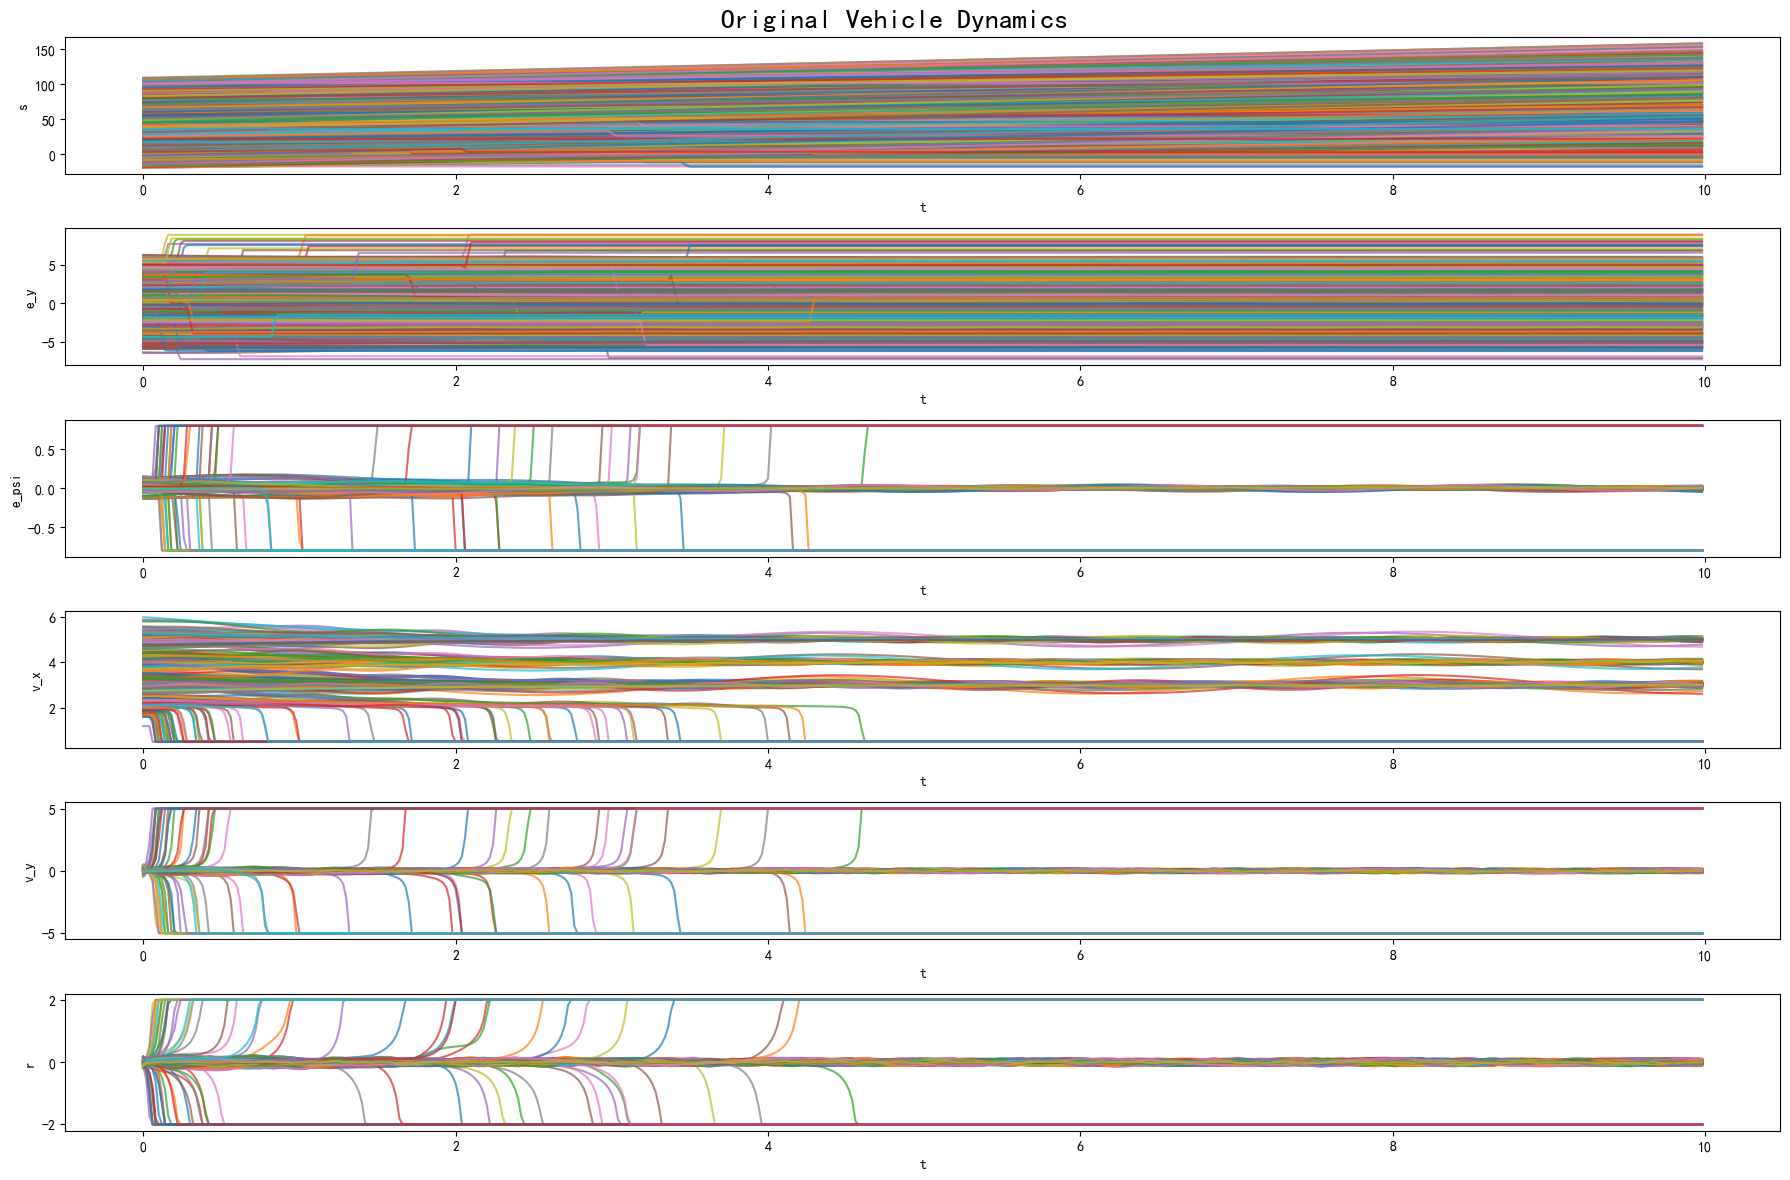

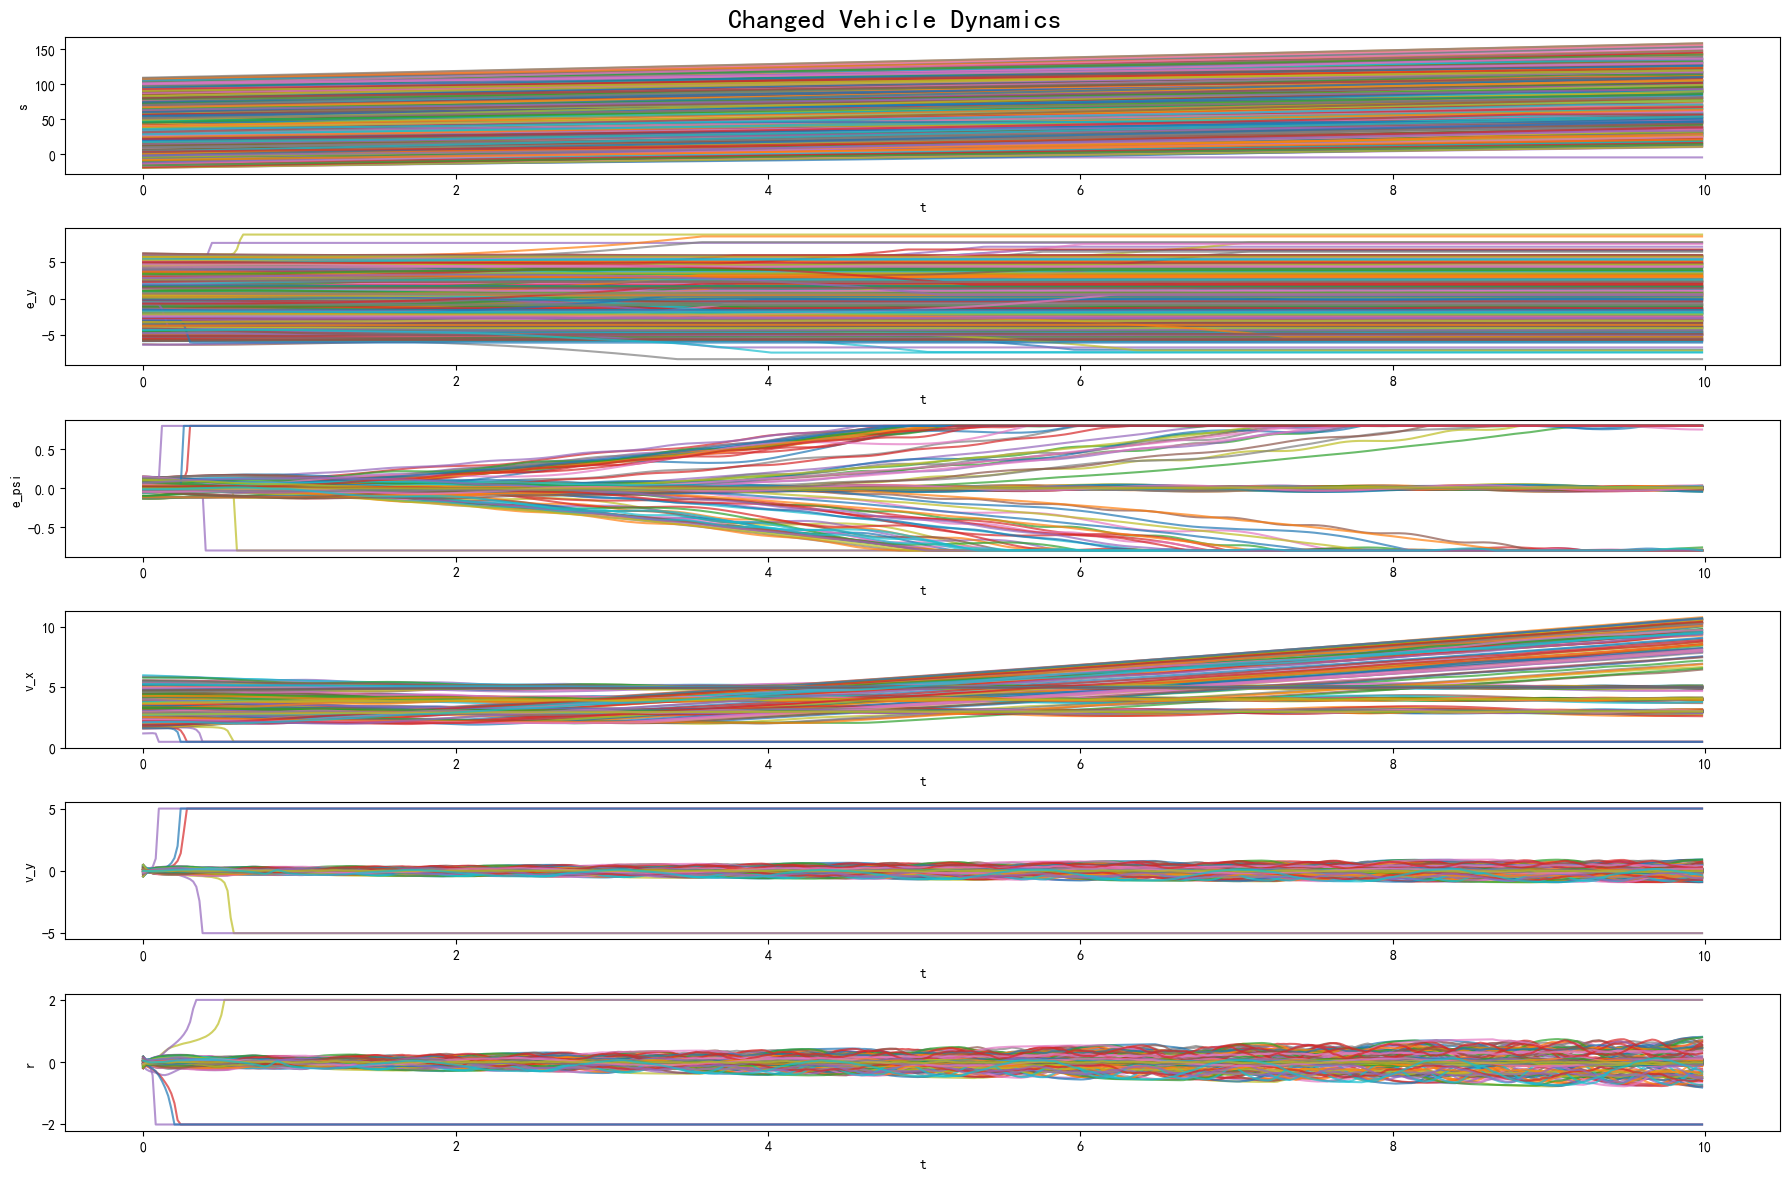

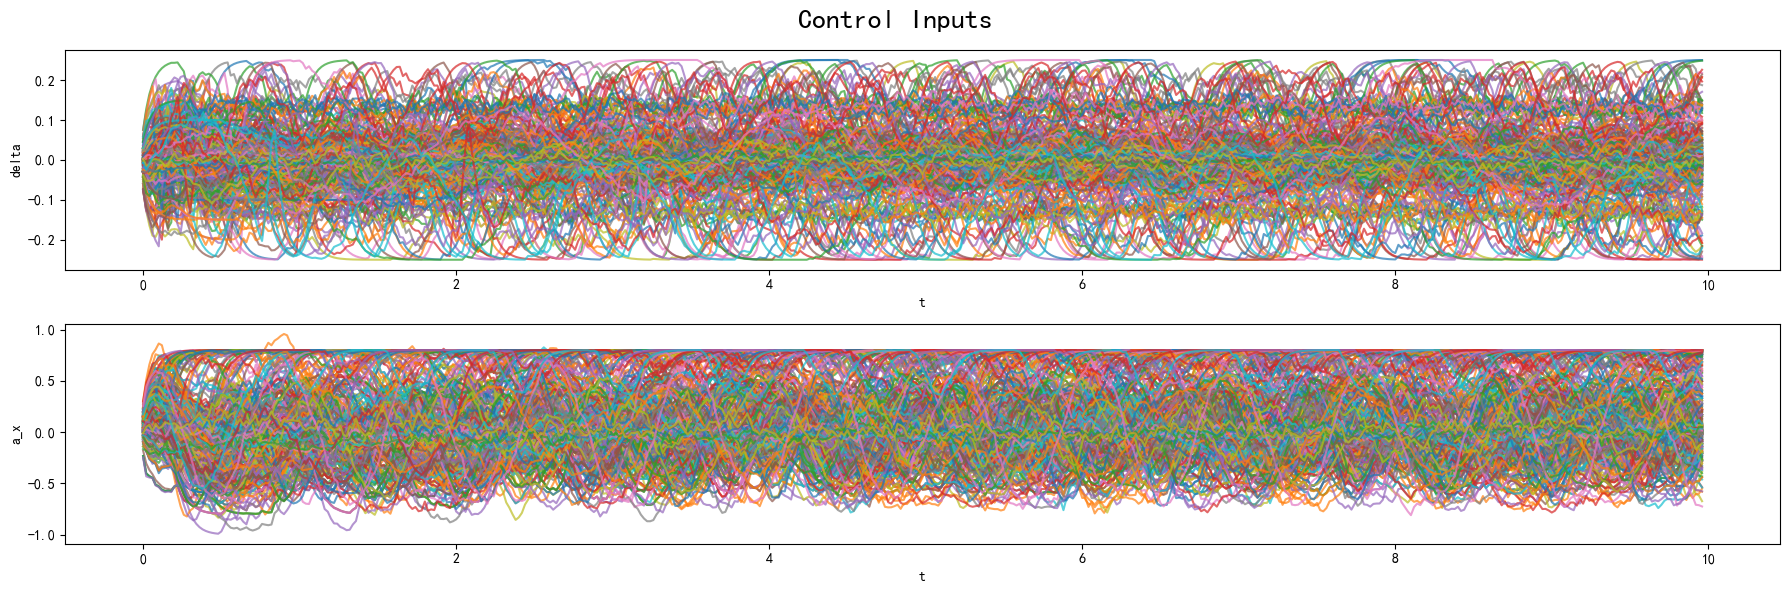

In [2]:

# =============================================================================
# 系统拟合
# =============================================================================
linear = True

# =============================================================================
# 数据生成 (针对 100m 双移线优化：丰富场景 + 物理不变性数据增强)
# =============================================================================
sys_pars_base = {}

# 6 states: x=[s, e_y, e_psi, v_x, v_y, r]
num_states = 6
num_inputs = 2
dt = 0.02

sys_pars_base["num_states"] = num_states
sys_pars_base["num_inputs"] = num_inputs
sys_pars_base["dt"] = dt

# nominal vehicle parameters
sys_pars_base["m"] = 1500.0
sys_pars_base["Iz"] = 2250.0
sys_pars_base["lf"] = 1.2
sys_pars_base["lr"] = 1.6
sys_pars_base["Cf"] = 80000.0
sys_pars_base["Cr"] = 80000.0
sys_pars_base["curvature_ref"] = 0.0
sys_pars_base["uncertainty"] = "NA"
sys_pars_base["amp"] = 0.0

sys_pars_base["road_modes"] = ['dlc']
sys_pars_base["road_mode_probs"] = [1.0]

sys_pars_base["u_modes"] = ['feedback_dominant', 'sinusoidal', 'mixed']
sys_pars_base["u_mode_probs"] = [0.40, 0.30, 0.30]  # 稍微调整激励比例

sys_pars_base["alpha_u"] = 0.70
sys_pars_base["s_margin"] = 15.0
sys_pars_base["seed"] = 42

# changed vehicle parameters
sys_pars_new_base = dict(sys_pars_base)
sys_pars_new_base["m"] = 1650.0
sys_pars_new_base["Iz"] = 2400.0
sys_pars_new_base["Cf"] = 70000.0
sys_pars_new_base["Cr"] = 70000.0

# sys_pars_new_base = dict(sys_pars_base)

sensor_noise = False
SNR_DB = 30
num_snaps = 500

configs = [
    {"vx_ref": 3.0, "delta_max": 0.10, "ax_max": 0.6, "freq": 1.0},
    {"vx_ref": 3.0, "delta_max": 0.20, "ax_max": 1.0, "freq": 0.5},  # 低频大转角，逼近紧急 DLC
    {"vx_ref": 4.0, "delta_max": 0.15, "ax_max": 0.8, "freq": 0.2},  # 中高速覆盖，拉大 e_y 侧移
    {"vx_ref": 5.0, "delta_max": 0.10, "ax_max": 0.8, "freq": 0.5},  # 高速覆盖
    {"vx_ref": 2.0, "delta_max": 0.25, "ax_max": 0.8, "freq": 0.5},  # 低速极大转角
]

num_traj_per_batch = 80
X_list, X_changed_list, U_list = [], [], []

print("正在生成覆盖双移线边界条件的多场景数据...")
for cfg in configs:
    sp = dict(sys_pars_base)
    sp.update(cfg)
    # sp["U_type"] = "sinusoidal"

    sp_new = dict(sys_pars_new_base)
    sp_new.update(cfg)
    # sp_new["U_type"] = "sinusoidal"

    X_b, X_changed_b, U_b = single_vehicle_data_gen_multi(
        num_traj_per_batch, num_snaps, sp, sp_new, sensor_noise, SNR_DB
    )
    X_list.append(X_b)
    X_changed_list.append(X_changed_b)
    U_list.append(U_b)

X = np.concatenate(X_list, axis=0)
X_changed = np.concatenate(X_changed_list, axis=0)
U = np.concatenate(U_list, axis=0)
num_traj = X.shape[0]  # Total 400

# 2. 【核心】数据增强 (Data Augmentation)
# 因为在直道上 (curvature_ref=0) 车辆的动态方程不受绝对纵向距离 s 和横向偏移 e_y 的影响
# 所以我们可以直接随机平移 s 和 e_y，扩大 Standardizer 的分布覆盖面，彻底解决饱和越界问题！
np.random.seed(42)

# 示例：生成 Koopman 训练数据时的初始化
for i in range(num_traj):
    # 【修改这里】：在真实的物理起点引入随机偏差，而不是事后改数据！
    init_s = np.random.uniform(-10.0, 50.0)
    init_ey = np.random.uniform(-6.0, 6.0)   # 覆盖编队所需的 4.0m 偏移
    init_epsi = np.random.uniform(-0.2, 0.2)

    # 将这些随机初始状态输入到你的环境/模型中进行正确的动力学积分
    state = [init_s, init_ey, init_epsi, init_v, ...]

    # 然后跑循环收集这整条 trajectory
    # traj = simulate_physics(state)
    # X.append(traj)
# for i in range(num_traj):
    # s_shift = np.random.uniform(-20.0, 110.0)  # 覆盖 DLC 的 100m 长度
    # ey_shift = np.random.uniform(-6.0, 6.0)  # 覆盖 DLC 的侧向偏差并留出充足泛化裕度
    #
    # X[i, :, 0] += s_shift
    # X_changed[i, :, 0] += s_shift
    # X[i, :, 1] += ey_shift
    # X_changed[i, :, 1] += ey_shift

# 打乱数据以防止验证集切分时分布不均
indices = np.random.permutation(num_traj)
X = X[indices]
X_changed = X_changed[indices]
U = U[indices]

num_train = int(0.8 * num_traj)
num_val = num_traj - num_train

# 恢复默认的 sys_pars 用于后续代码流转基准
# sys_pars = dict(sys_pars_base)
# sys_pars.update({"vx_ref": 3.0, "delta_max": 0.05, "ax_max": 0.6, "freq": 1.0, "U_type": "sinusoidal"})
# sys_pars_new = dict(sys_pars_new_base)
# sys_pars_new.update({"vx_ref": 3.0, "delta_max": 0.05, "ax_max": 0.6, "freq": 1.0, "U_type": "sinusoidal"})

sys_pars = dict(sys_pars_base)
sys_pars.update({"vx_ref": 3.0, "delta_max": 0.05, "ax_max": 0.6, "freq": 1.0})

sys_pars_new = dict(sys_pars_new_base)
sys_pars_new.update({"vx_ref": 3.0, "delta_max": 0.05, "ax_max": 0.6, "freq": 1.0})

print("X shape:", X.shape)
print("X_changed shape:", X_changed.shape)
print("U shape:", U.shape)

os.makedirs("saved_data/single_vehicle", exist_ok=True)

np.savez_compressed(
    "saved_data/single_vehicle/offline_dataset.npz",
    X=X,
    X_changed=X_changed,
    U=U
)

with open("saved_data/single_vehicle/offline_dataset_pars.pkl", "wb") as f:
    pickle.dump({
        "sys_pars": sys_pars,
        "sys_pars_new": sys_pars_new,
        "num_traj": num_traj,
        "num_train": num_train,
        "num_val": num_val,
        "num_snaps": num_snaps,
        "sensor_noise": sensor_noise,
        "SNR_DB": SNR_DB
    }, f)

print("离线数据已保存。")

state_labels = ["s", "e_y", "e_psi", "v_x", "v_y", "r"]
input_labels = ["delta", "a_x"]
t_train = np.linspace(0, dt * (num_snaps - 1), num_snaps)

plt.figure(figsize=(18, 12))
for j in range(num_traj):
    for i in range(num_states):
        plt.subplot(num_states, 1, i + 1)
        plt.plot(t_train, X[j, :, i], alpha=0.7)
        plt.ylabel(state_labels[i])
        plt.xlabel("t")
plt.suptitle("Original Vehicle Dynamics", fontsize=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 12))
for j in range(num_traj):
    for i in range(num_states):
        plt.subplot(num_states, 1, i + 1)
        plt.plot(t_train, X_changed[j, :, i], alpha=0.7)
        plt.ylabel(state_labels[i])
        plt.xlabel("t")
plt.suptitle("Changed Vehicle Dynamics", fontsize=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 6))
for j in range(num_traj):
    for i in range(num_inputs):
        plt.subplot(num_inputs, 1, i + 1)
        plt.plot(t_train[:-1], U[j, :, i], alpha=0.7)
        plt.ylabel(input_labels[i])
        plt.xlabel("t")
plt.suptitle("Control Inputs", fontsize=20)
plt.tight_layout()
plt.show()

Model save path: saved_models/single_vehicle/linear/Koop_vehicle_Dim16_dt_0.02.pth
✅ U_curr 与 X_curr 样本数匹配: 159680
✅ U_curr 与 X_curr 样本数匹配: 39920
Epoch [  10/500] | Train  total=5.8468e-03  pred=5.6905e-04  lifted=1.5043e-04| Val    total=5.8442e-03  pred=7.1722e-04  lifted=1.8949e-04
Epoch [  20/500] | Train  total=3.6006e-03  pred=5.5793e-04  lifted=1.4833e-04| Val    total=3.6748e-03  pred=6.9885e-04  lifted=1.8507e-04
Epoch [  30/500] | Train  total=2.5104e-03  pred=5.4244e-04  lifted=1.4852e-04| Val    total=2.6217e-03  pred=6.8064e-04  lifted=1.8403e-04
Epoch [  40/500] | Train  total=1.9289e-03  pred=5.0591e-04  lifted=1.3679e-04| Val    total=2.0773e-03  pred=6.6251e-04  lifted=1.7724e-04
Epoch [  50/500] | Train  total=1.6327e-03  pred=5.2028e-04  lifted=1.4365e-04| Val    total=1.7556e-03  pred=6.4629e-04  lifted=1.7615e-04
Epoch [  60/500] | Train  total=1.3938e-03  pred=4.9876e-04  lifted=1.3178e-04| Val    total=1.5269e-03  pred=6.3108e-04  lifted=1.6618e-04
Epoch [  70/50

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Epoch [ 500/500] | Train  total=4.6242e-04  pred=4.2784e-04  lifted=1.1170e-04| Val    total=5.7458e-04  pred=5.3187e-04  lifted=1.3884e-04
✅ Koopman模型构造完成 | A: (23, 23) | B: (23, 2) | C: (6, 23)


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

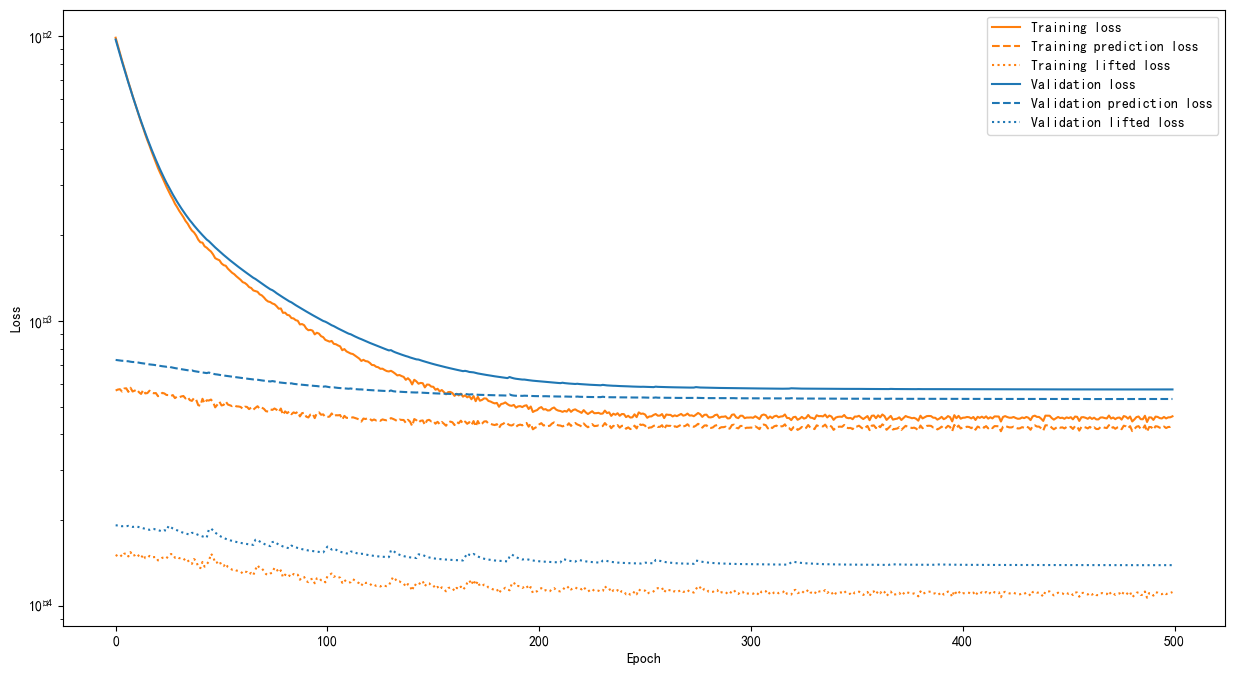

In [3]:

# =============================================================================
# Learning Koopman
# =============================================================================
xs_train, us_train = X[:num_train, :, :], U[:num_train, :, :]
xs_val, us_val = X[num_train:, :, :], U[num_train:, :, :]

net_params_lin = {}
net_params_lin["state_dim"] = num_states
net_params_lin["ctrl_dim"] = num_inputs
net_params_lin["encoder_hidden_width"] = 128
# 模型容量适度提升：场景增多变复杂了，给隐变量输出更多维度
net_params_lin["encoder_hidden_depth"] = 4
net_params_lin["encoder_output_dim"] = 16
net_params_lin["optimizer"] = "adam"
net_params_lin["activation_type"] = "tanh"
net_params_lin["lr"] = 1e-4
net_params_lin["epochs"] = 500
net_params_lin["batch_size"] = 6144

net_params_lin["eig_loss"] = True
net_params_lin["eig_loss_coeff"] = 0.5
net_params_lin["lifted_loss_penalty"] = 0.3

net_params_lin["l2_reg"] = 5e-5
net_params_lin["l1_reg"] = 1e-7
net_params_lin["first_obs_const"] = True
net_params_lin["override_C"] = True
net_params_lin["dt"] = dt

train = True
standardize = True

os.makedirs("saved_models/single_vehicle/linear", exist_ok=True)

file_koop_linear = (
        "saved_models/single_vehicle/linear/"
        + "Koop_vehicle_Dim"
        + str(net_params_lin["encoder_output_dim"])
        + "_dt_"
        + str(dt)
        + ".pth"
)

print("Model save path:", file_koop_linear)

standardizer_u_kdnn = fit_standardizer(
    us_train, preprocessing.StandardScaler(with_mean=True)
)
standardizer_x_kdnn = fit_standardizer(
    xs_train, preprocessing.StandardScaler(with_mean=True)
)

if train:
    if standardize:
        net = KoopmanNetCtrl_linear(
            net_params_lin,
            standardizer_x=standardizer_x_kdnn,
            standardizer_u=standardizer_u_kdnn,
            device=DEVICE
        )
    else:
        net = KoopmanNetCtrl_linear(
            net_params_lin,
            device=DEVICE
        )

    model_koop_dnn_lin = KoopDNN_linear(net)
    model_koop_dnn_lin.set_datasets(
        xs_train,
        u_train=us_train,
        x_val=xs_val,
        u_val=us_val
    )
    model_koop_dnn_lin.model_pipeline(net_params_lin)
    model_koop_dnn_lin.construct_koopman_model()

    torch.save(model_koop_dnn_lin, file_koop_linear)
else:
    model_koop_dnn_lin = torch.load(file_koop_linear, map_location=DEVICE)
    model_koop_dnn_lin.net.to(DEVICE)
    model_koop_dnn_lin.net.device = DEVICE

train_loss = [l[0] for l in model_koop_dnn_lin.train_loss_hist]
train_pred_loss = [l[1] for l in model_koop_dnn_lin.train_loss_hist]
train_lifted_loss = [l[2] for l in model_koop_dnn_lin.train_loss_hist]
val_loss = [l[0] for l in model_koop_dnn_lin.val_loss_hist]
val_pred_loss = [l[1] for l in model_koop_dnn_lin.val_loss_hist]
val_lifted_loss = [l[2] for l in model_koop_dnn_lin.val_loss_hist]
epochs = np.arange(0, net_params_lin["epochs"])

plt.figure(figsize=(15, 8))
plt.plot(epochs, train_loss, color="tab:orange", label="Training loss")
plt.plot(epochs, train_pred_loss, "--", color="tab:orange", label="Training prediction loss")
plt.plot(epochs, train_lifted_loss, ":", color="tab:orange", label="Training lifted loss")
plt.plot(epochs, val_loss, color="tab:blue", label="Validation loss")
plt.plot(epochs, val_pred_loss, "--", color="tab:blue", label="Validation prediction loss")
plt.plot(epochs, val_lifted_loss, ":", color="tab:blue", label="Validation lifted loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.show()

✅ A_lin shape: (23, 23)
✅ B_lin shape: (23, 2)
✅ C_lin shape: (6, 23)
stable spectral radius = 0.9990002
A, B, C shapes: (23, 23) (23, 2) (6, 23)
spectral radius = 0.9997925
eigvals = [0.86357147+0.12347381j 0.86357147-0.12347381j 0.99763995+0.01756123j
 0.99763995-0.01756123j 0.9951163 +0.01399944j 0.9951163 -0.01399944j
 0.99150175+0.0102644j  0.99150175-0.0102644j  0.9997918 +0.00122394j
 0.9997918 -0.00122394j 0.9996087 +0.00165041j 0.9996087 -0.00165041j
 0.9990842 +0.j         0.9935603 +0.00625155j 0.9935603 -0.00625155j
 0.98871595+0.00587464j 0.98871595-0.00587464j 0.9886841 +0.j
 0.9903315 +0.00486978j 0.9903315 -0.00486978j 0.9921135 +0.00382585j
 0.9921135 -0.00382585j 0.9918137 +0.j        ]


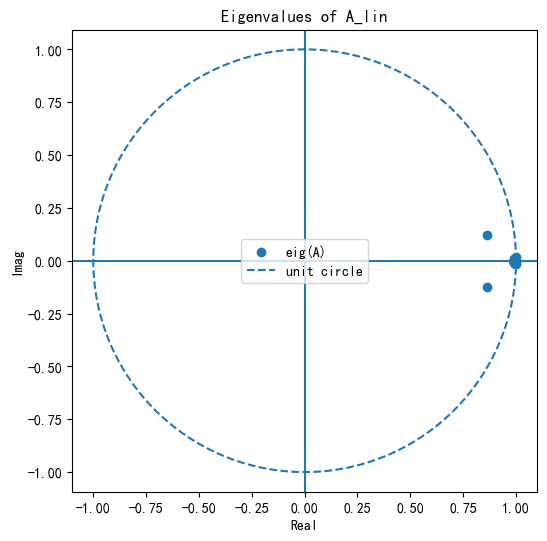

✅ U_curr 与 X_curr 样本数匹配: 99
✅ U_curr 与 X_curr 样本数匹配: 99
x_unchanged_scaled shape: (99, 6)
u_scaled shape: (99, 2)
x_changed_scaled shape: (99, 6)
x_changed_prime_scaled shape: (99, 0)


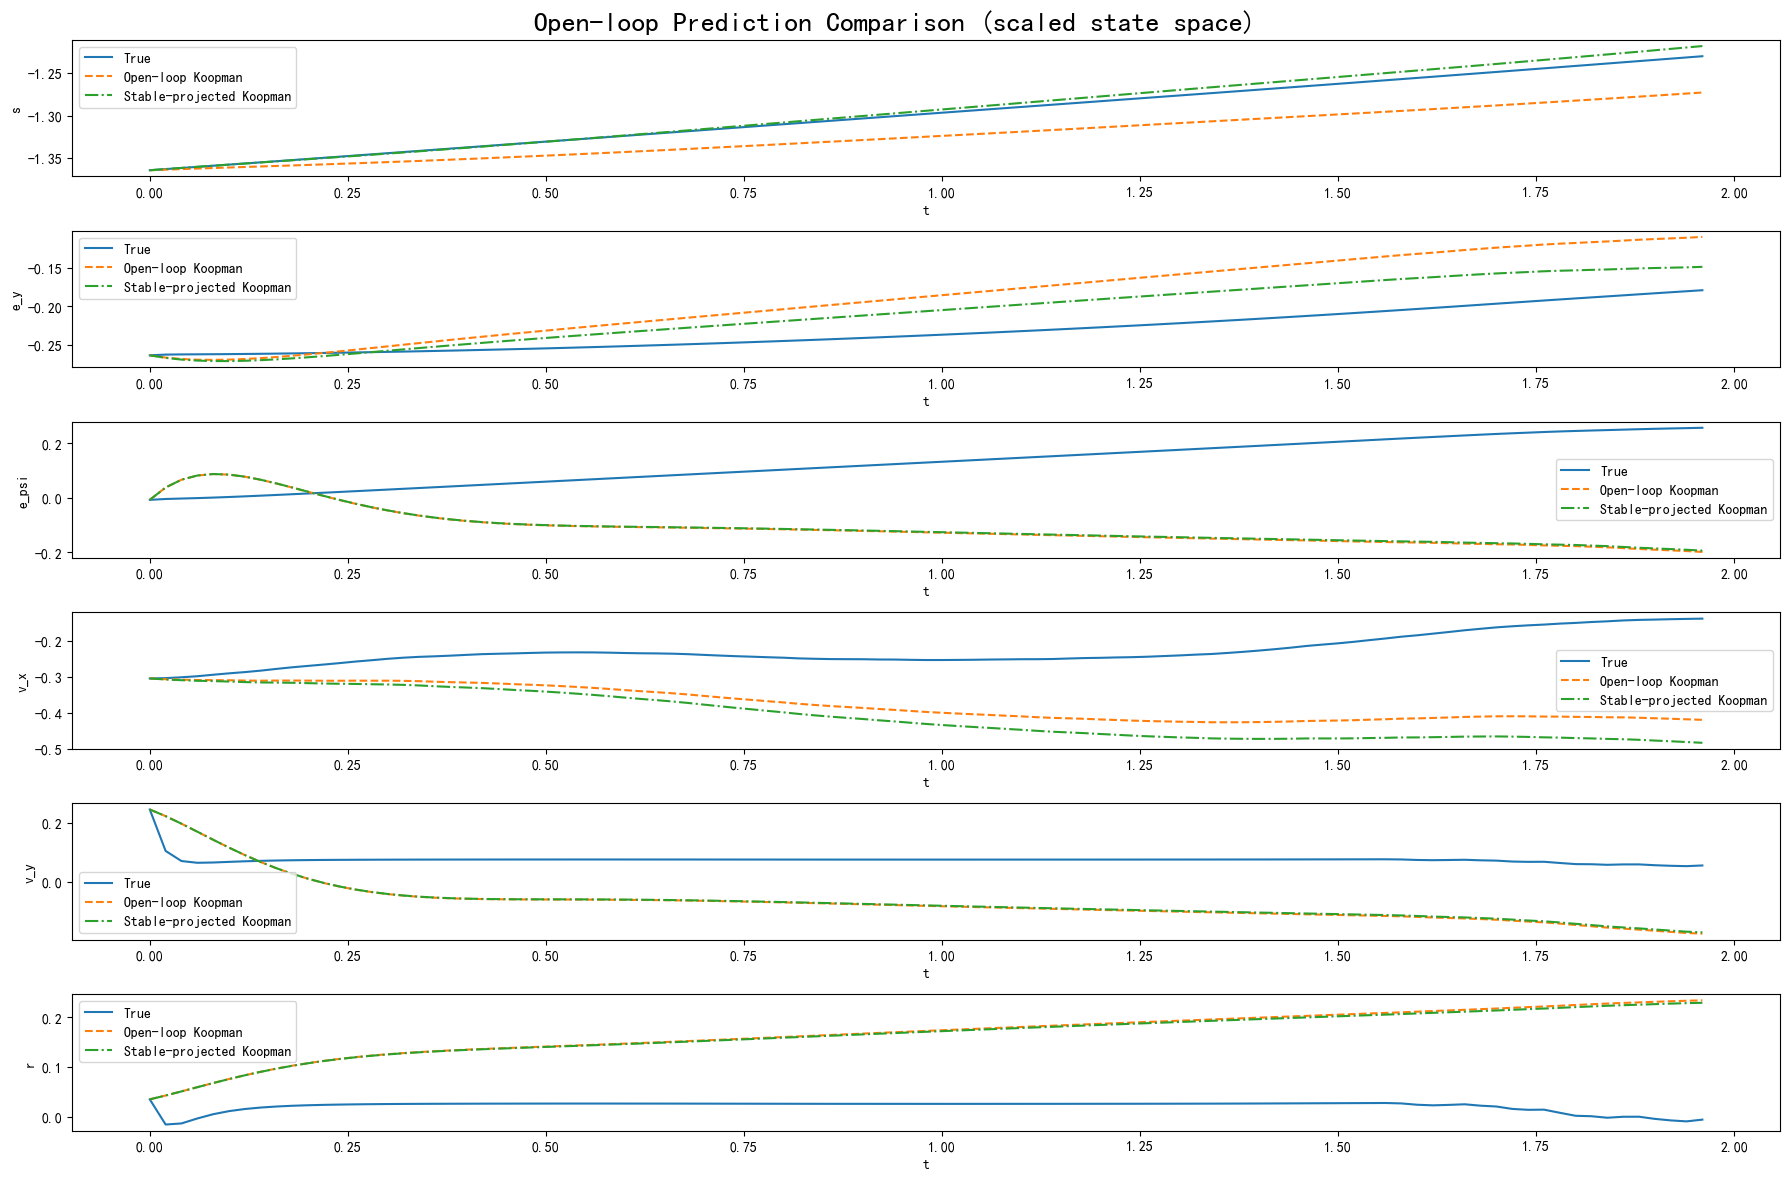

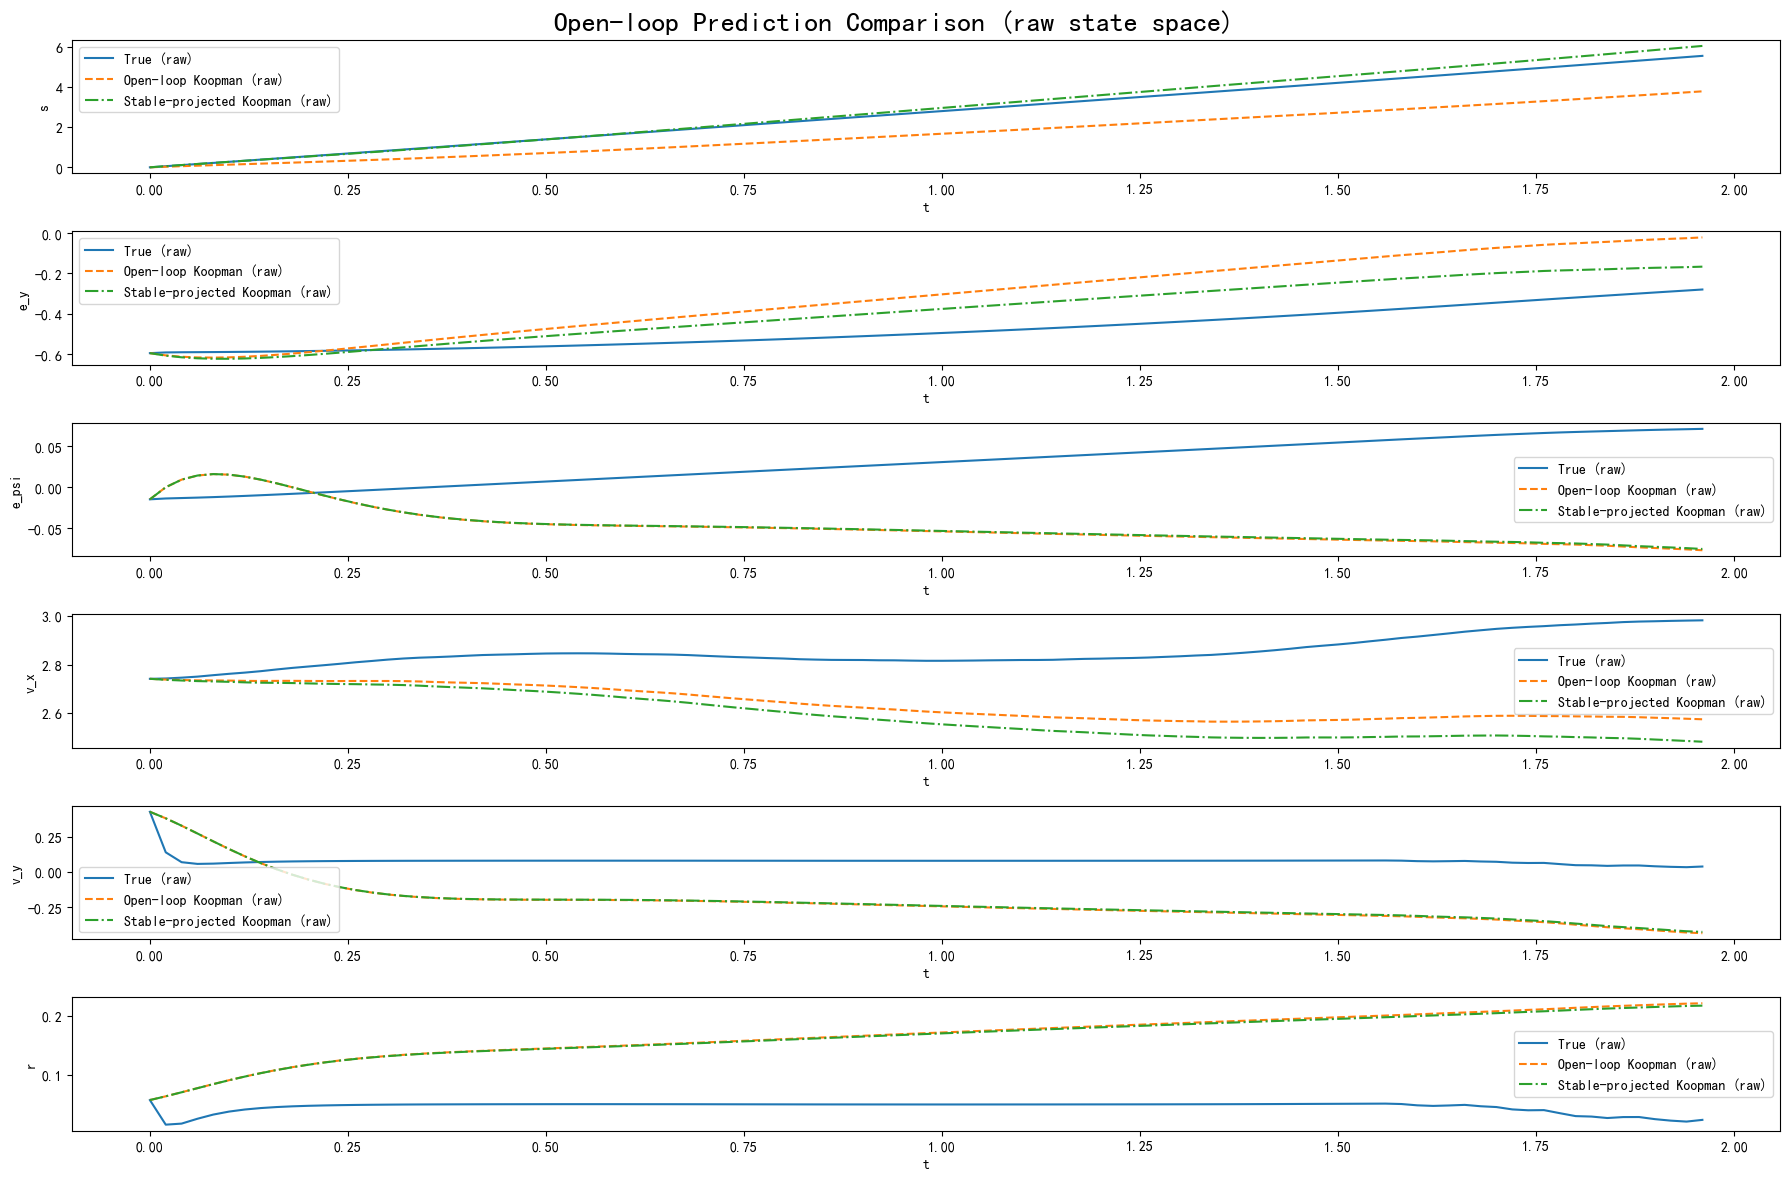

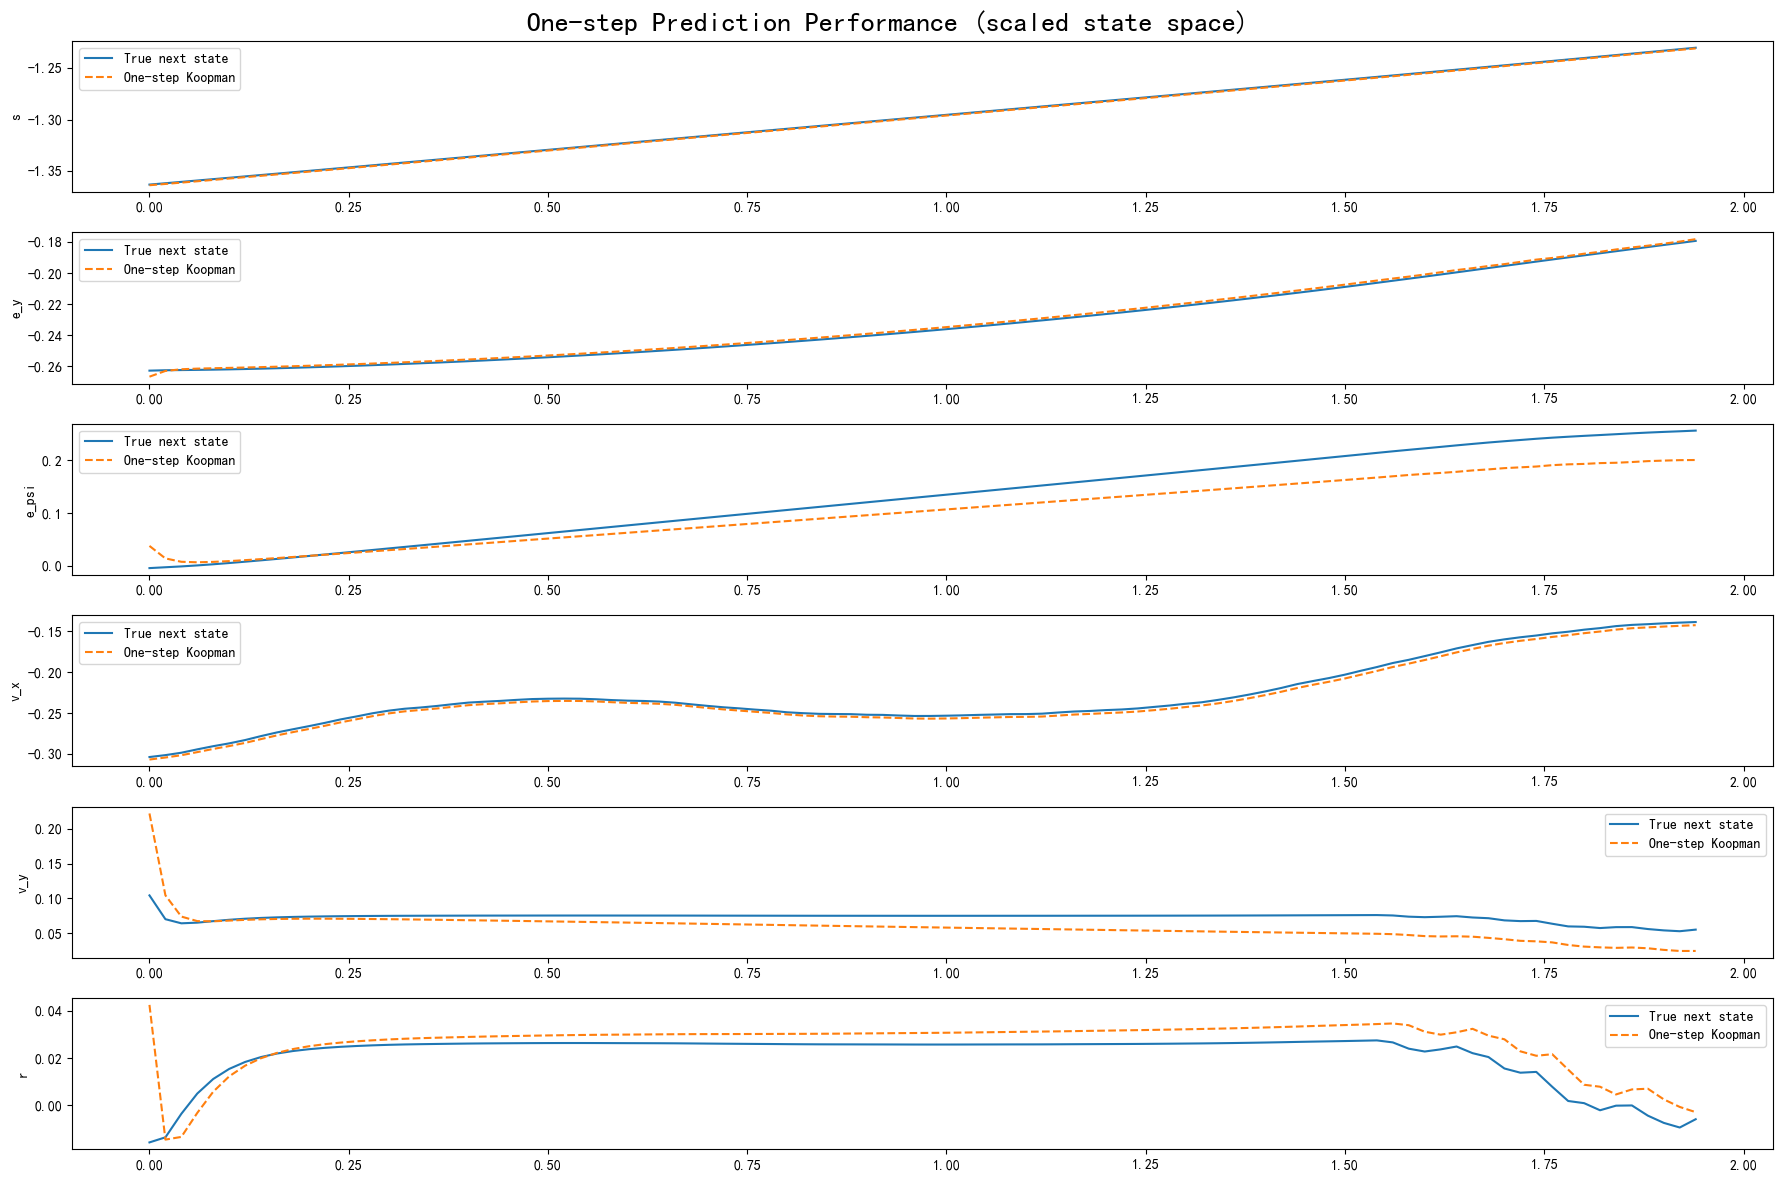

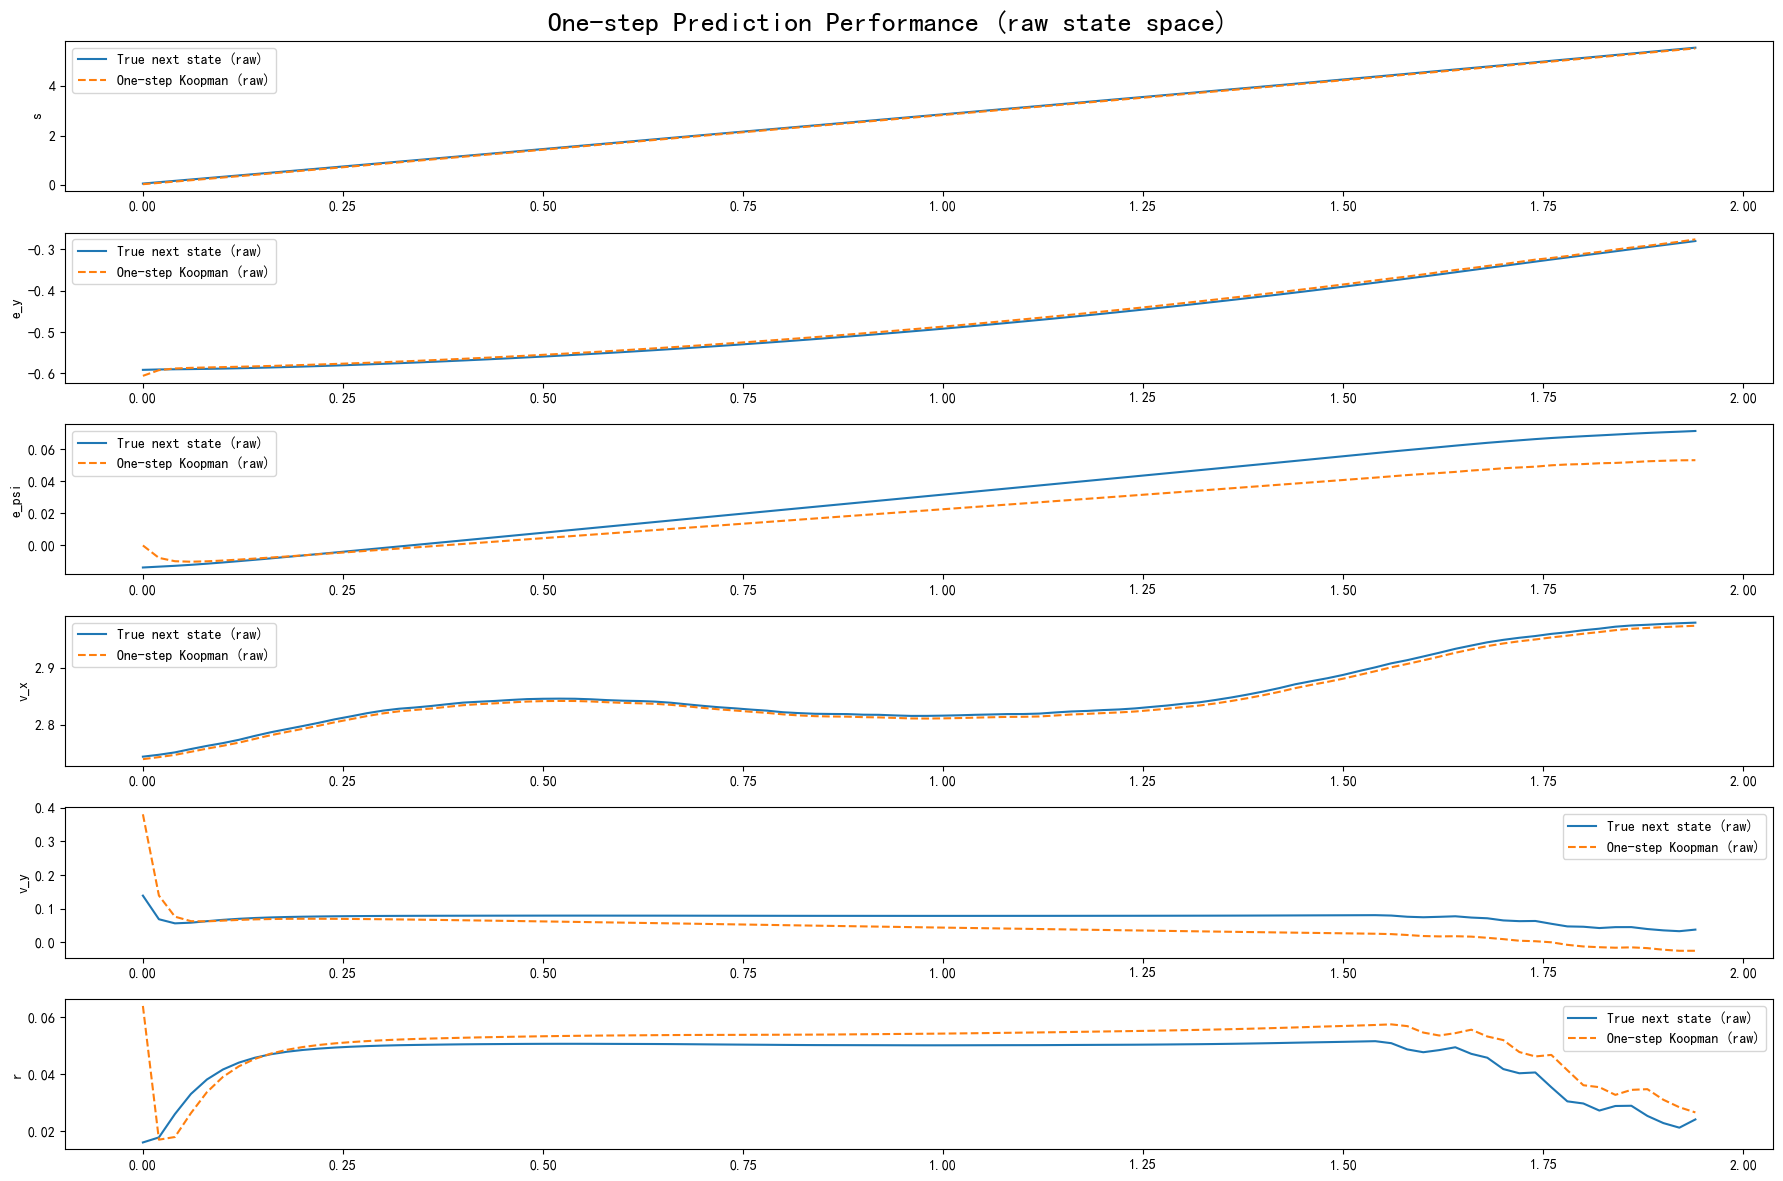

In [4]:

# =============================================================================
# Koopman Model Parameters (Open Loop Test)
# =============================================================================
num_snaps_test = 100
T_test = np.linspace(0, (num_snaps_test - 1) * dt, num_snaps_test)

num_traj_test = 1
first_obs_const = int(net_params_lin["first_obs_const"])
override_C = net_params_lin["override_C"]
if override_C:
    n_obs_lin = int(net_params_lin["encoder_output_dim"]) + num_states + first_obs_const
else:
    n_obs_lin = int(net_params_lin["encoder_output_dim"]) + first_obs_const

x_unchanged_test, x_changed_test, u_test = single_vehicle_data_gen_multi(
    num_traj_test, num_snaps_test, sys_pars, sys_pars_new, sensor_noise, SNR_DB
)

# ===== 关键修复：正确提取 A、B、C =====
net = model_koop_dnn_lin.net
A_lin = to_numpy(net.A.weight)
B_lin = to_numpy(net.B.weight)
C_lin = to_numpy(net.C.weight)

print("✅ A_lin shape:", A_lin.shape)
print("✅ B_lin shape:", B_lin.shape)
print("✅ C_lin shape:", C_lin.shape)


eigvals, eigvecs = np.linalg.eig(A_lin)
eigvals_proj = np.array([
    ev if np.abs(ev) <= 0.999 else ev / np.abs(ev) * 0.999
    for ev in eigvals
])
A_lin_stable = eigvecs @ np.diag(eigvals_proj) @ np.linalg.inv(eigvecs)
A_lin_stable = np.real(A_lin_stable)

eigvals_stable = np.linalg.eigvals(A_lin_stable)
print("stable spectral radius =", np.max(np.abs(eigvals_stable)))

print("A, B, C shapes:", A_lin.shape, B_lin.shape, C_lin.shape)

eigvals = np.linalg.eigvals(A_lin)
spectral_radius = np.max(np.abs(eigvals))

print("spectral radius =", spectral_radius)
print("eigvals =", eigvals)

plt.figure(figsize=(6, 6))
plt.scatter(np.real(eigvals), np.imag(eigvals), label="eig(A)")
theta = np.linspace(0, 2 * np.pi, 400)
plt.plot(np.cos(theta), np.sin(theta), "--", label="unit circle")
plt.axhline(0)
plt.axvline(0)
plt.xlabel("Real")
plt.ylabel("Imag")
plt.legend()
plt.title("Eigenvalues of A_lin")
plt.axis("equal")
plt.show()

X_unchanged_scaled, _ = model_koop_dnn_lin.net.process(x_unchanged_test, data_u=u_test)
X_changed_scaled, _ = model_koop_dnn_lin.net.process(x_changed_test, data_u=u_test)

x_unchanged_scaled = X_unchanged_scaled[:, :num_states]
u_scaled = X_unchanged_scaled[:, num_states:num_states + num_inputs]
x_unchanged_prime_scaled = X_unchanged_scaled[:, num_states + num_inputs:]

x_changed_scaled = X_changed_scaled[:, :num_states]
x_changed_prime_scaled = X_changed_scaled[:, num_states + num_inputs:]

print("x_unchanged_scaled shape:", x_unchanged_scaled.shape)
print("u_scaled shape:", u_scaled.shape)
print("x_changed_scaled shape:", x_changed_scaled.shape)
print("x_changed_prime_scaled shape:", x_changed_prime_scaled.shape)

num_pred = x_unchanged_scaled.shape[0]

z_lin = np.zeros((num_pred, n_obs_lin))
x_est_lin = np.zeros((num_pred, num_states))

z_lin[0, :] = lift_scaled(x_unchanged_scaled[0, :], model_koop_dnn_lin, net_params_lin)
x_est_lin[0, :] = np.matmul(z_lin[0, :], C_lin.T)

for k in range(num_pred - 1):
    z_lin[k + 1, :] = np.matmul(z_lin[k, :], A_lin.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_est_lin[k + 1, :] = np.matmul(z_lin[k + 1, :], C_lin.T)

z_lin_stable = np.zeros((num_pred, n_obs_lin))
x_est_lin_stable = np.zeros((num_pred, num_states))

z_lin_stable[0, :] = lift_scaled(x_unchanged_scaled[0, :], model_koop_dnn_lin, net_params_lin)
x_est_lin_stable[0, :] = np.matmul(z_lin_stable[0, :], C_lin.T)

for k in range(num_pred - 1):
    z_lin_stable[k + 1, :] = np.matmul(z_lin_stable[k, :], A_lin_stable.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_est_lin_stable[k + 1, :] = np.matmul(z_lin_stable[k + 1, :], C_lin.T)

T_plot = np.arange(num_pred) * dt

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.xlabel("t")
    plt.ylabel(state_labels[i])
    plt.plot(T_plot, x_unchanged_scaled[:, i], label="True")
    plt.plot(T_plot, x_est_lin[:, i], "--", label="Open-loop Koopman")
    plt.plot(T_plot, x_est_lin_stable[:, i], "-.", label="Stable-projected Koopman")
    plt.legend()

plt.suptitle("Open-loop Prediction Comparison (scaled state space)", fontsize=20)
plt.tight_layout()
plt.show()

x_est_lin_raw = standardizer_x_kdnn.inverse_transform(x_est_lin)
x_est_lin_stable_raw = standardizer_x_kdnn.inverse_transform(x_est_lin_stable)
x_true_raw = x_unchanged_test[0, :-1, :]

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.xlabel("t")
    plt.ylabel(state_labels[i])
    plt.plot(T_plot, x_true_raw[:, i], label="True (raw)")
    plt.plot(T_plot, x_est_lin_raw[:, i], "--", label="Open-loop Koopman (raw)")
    plt.plot(T_plot, x_est_lin_stable_raw[:, i], "-.", label="Stable-projected Koopman (raw)")
    plt.legend()

plt.suptitle("Open-loop Prediction Comparison (raw state space)", fontsize=20)
plt.tight_layout()
plt.show()


# =============================================================================
# 单步预测（修复版）
# =============================================================================
num_pred_1step = x_unchanged_scaled.shape[0] - 1
x_one_step_pred = np.zeros((num_pred_1step, num_states))

for k in range(num_pred_1step):
    z_k  = lift_scaled(x_unchanged_scaled[k, :], model_koop_dnn_lin, net_params_lin)
    z_k1 = np.matmul(z_k, A_lin.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_one_step_pred[k, :] = np.matmul(z_k1, C_lin.T)

# 真值：下一时刻的 scaled 状态
x_unchanged_prime_scaled = x_unchanged_scaled[1:, :]   # (num_pred-1, num_states)

T_plot_1 = np.arange(num_pred_1step) * dt

# --- scaled 空间对比图 ---
plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(T_plot_1, x_unchanged_prime_scaled[:, i], label="True next state")
    plt.plot(T_plot_1, x_one_step_pred[:, i], "--", label="One-step Koopman")
    plt.ylabel(state_labels[i])
    plt.legend()
plt.suptitle("One-step Prediction Performance (scaled state space)", fontsize=20)
plt.tight_layout()
plt.show()

# --- raw 空间对比图 ---
x_one_step_pred_raw = standardizer_x_kdnn.inverse_transform(x_one_step_pred)
x_true_next_raw     = x_unchanged_test[0, 1:num_pred, :]   # shape: (num_pred-1, num_states)

T_plot_raw = np.arange(x_true_next_raw.shape[0]) * dt

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(T_plot_raw, x_true_next_raw[:, i], label="True next state (raw)")
    plt.plot(T_plot_raw, x_one_step_pred_raw[:, i], "--", label="One-step Koopman (raw)")
    plt.ylabel(state_labels[i])
    plt.legend()
plt.suptitle("One-step Prediction Performance (raw state space)", fontsize=20)
plt.tight_layout()
plt.show()


In [5]:
# ====================== 四车矩形编队参数 ======================
NUM_VEHICLES = 4

# 矩形队形期望间距（单位：米）
DESIRED_LONGITUDINAL_GAP = 8.0   # 前后车纵向间距
DESIRED_LATERAL_GAP     = 4.0    # 左右车横向间距

# 初始队形相对 Leader 的偏移 [Δs, Δe_y]
formation_offsets = np.array([
    [0.0, 0.0],                                   # Vehicle 0: Leader
    [0.0, DESIRED_LATERAL_GAP],                   # Vehicle 1: 右前方
    [-DESIRED_LONGITUDINAL_GAP, 0.0],             # Vehicle 2: 左后方
    [-DESIRED_LONGITUDINAL_GAP, DESIRED_LATERAL_GAP]  # Vehicle 3: 右后方
])

Q_formation = 800.0   # 队形保持额外惩罚权重（可调）

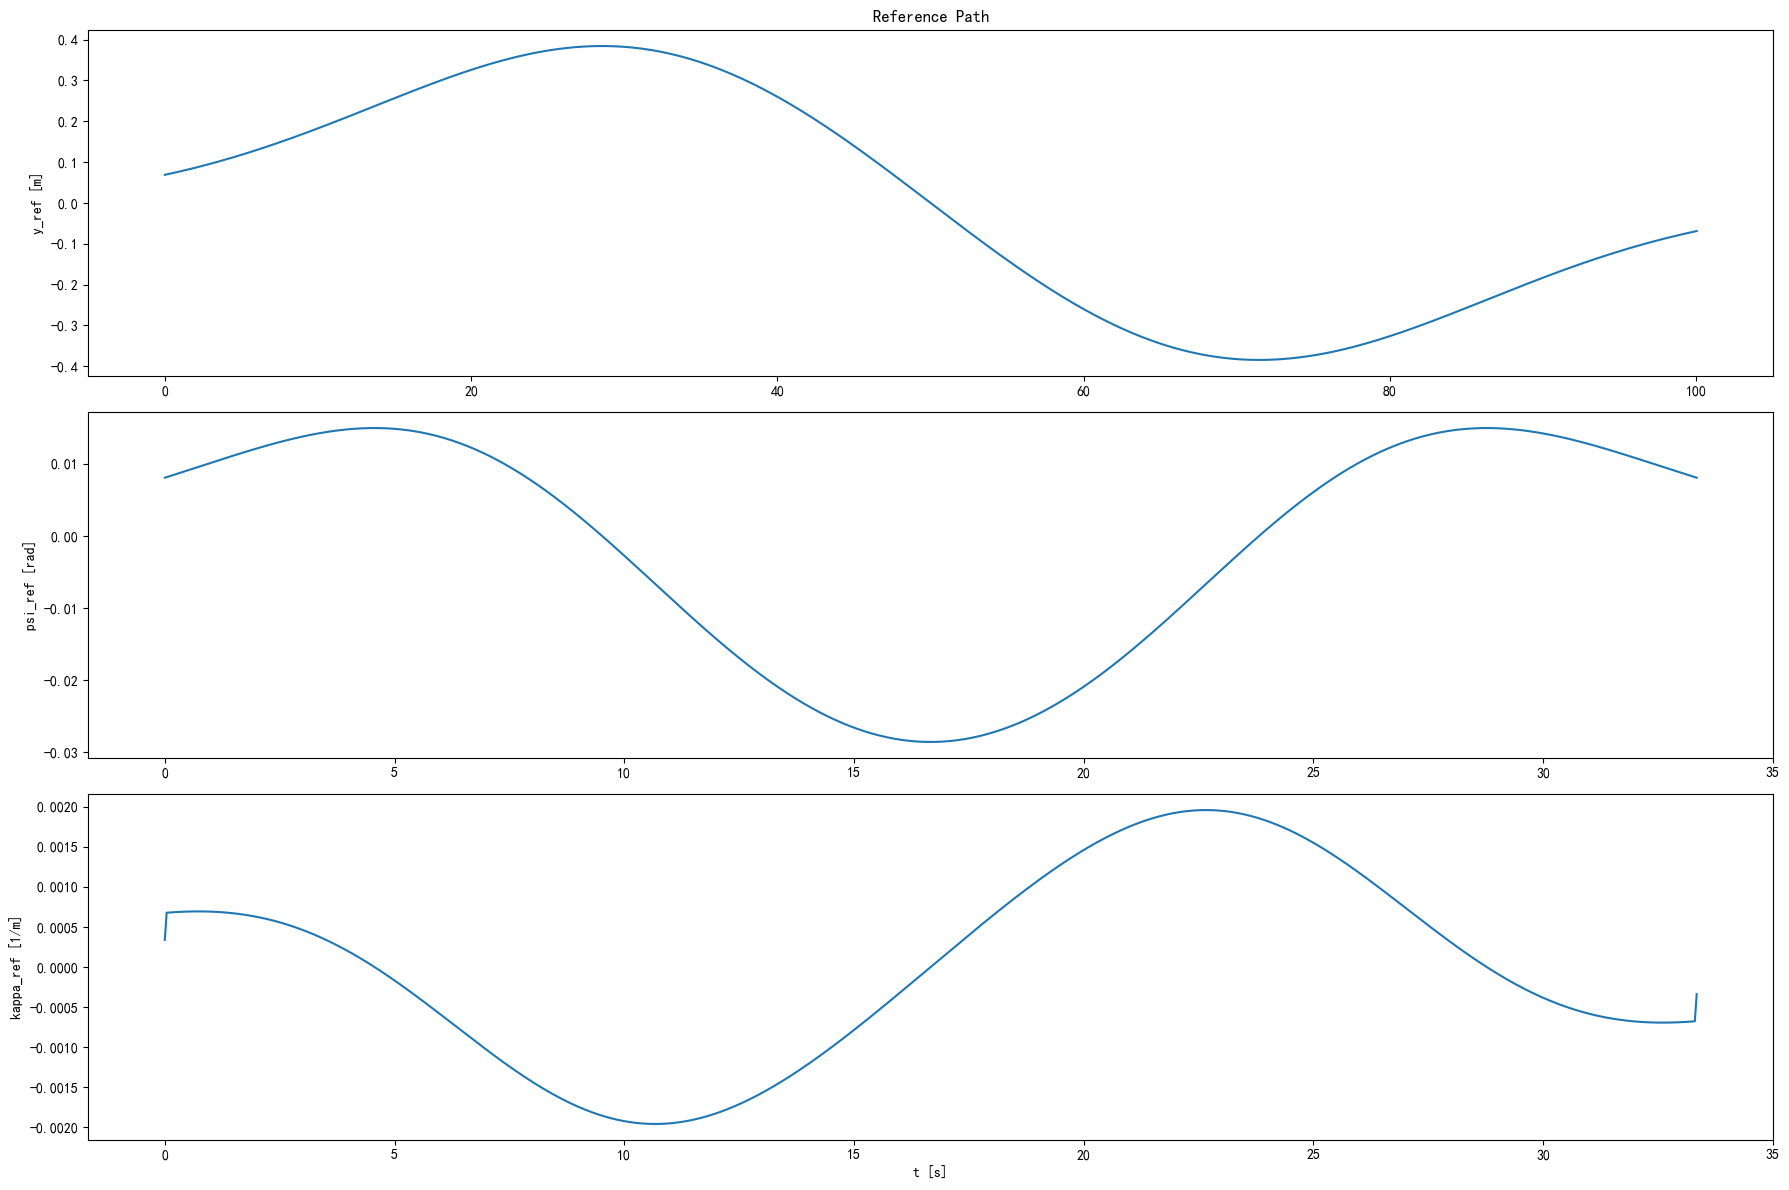

In [6]:

# =============================================================================
# Testing - 100m Double Lane Change Baseline
# =============================================================================

# =========================
# Reference path generation
# =========================
path_length = 100.0

vx_nom = 3.0
T_traj = path_length / vx_nom
t_ref = np.arange(0, T_traj + dt, dt)
traj_length = t_ref.size
x_path = vx_nom * t_ref

A1 = 0.4
A2 = -0.4
x1 = 30.0
x2 = 70.0
sigma1 = 16.0
sigma2 = 16.0

y_ref_path = (
        A1 * np.exp(-0.5 * ((x_path - x1) / sigma1) ** 2)
        + A2 * np.exp(-0.5 * ((x_path - x2) / sigma2) ** 2)
)

s_ref_path, psi_ref_path, curvature_ref_path = build_test_frenet_path_from_xy(
    x_path, y_ref_path
)

x_ref_raw = np.zeros((num_states, traj_length))
x_ref_raw[0, :] = s_ref_path
x_ref_raw[1, :] = 0.0
x_ref_raw[2, :] = 0.0
x_ref_raw[3, :] = vx_nom
x_ref_raw[4, :] = 0.0
x_ref_raw[5, :] = vx_nom * curvature_ref_path

x_ref_scaled = standardizer_x_kdnn.transform(x_ref_raw.T).T

plt.figure(figsize=(18, 12))
plt.subplot(3, 1, 1)
plt.plot(x_path, y_ref_path)
plt.ylabel("y_ref [m]")
plt.title("Reference Path")

plt.subplot(3, 1, 2)
plt.plot(t_ref, psi_ref_path)
plt.ylabel("psi_ref [rad]")

plt.subplot(3, 1, 3)
plt.plot(t_ref, curvature_ref_path)
plt.ylabel("kappa_ref [1/m]")
plt.xlabel("t [s]")
plt.tight_layout()
plt.show()

In [7]:
def generate_formation_reference(x_ref_scaled, formation_offsets, standardizer_x):
    """生成四车带偏移的参考轨迹（scaled空间）"""
    num_states_total = num_states * NUM_VEHICLES
    x_ref_formation = np.zeros((num_states_total, x_ref_scaled.shape[1]))

    for v in range(NUM_VEHICLES):
        offset_s  = formation_offsets[v, 0]
        offset_ey = formation_offsets[v, 1]
        idx = v * num_states

        x_ref_formation[idx:idx+num_states, :] = x_ref_scaled.copy()

        # 缩放空间下的偏移（除以对应标准差）
        x_ref_formation[idx + 0, :] += offset_s / standardizer_x.scale_[0]   # s
        x_ref_formation[idx + 1, :] += offset_ey / standardizer_x.scale_[1]  # e_y

    return x_ref_formation

In [8]:

# =========================
# Solver settings
# =========================
solver_settings = {}
solver_settings["gen_embedded_ctrl"] = False
solver_settings["warm_start"] = True
solver_settings["polish"] = True
solver_settings["polish_refine_iter"] = 5
solver_settings["scaling"] = True
solver_settings["adaptive_rho"] = True
solver_settings["check_termination"] = 25
solver_settings["max_iter"] = 30000
solver_settings["eps_abs"] = 5e-4
solver_settings["eps_rel"] = 5e-4
solver_settings["eps_prim_inf"] = 1e-3
solver_settings["eps_dual_inf"] = 1e-3

In [9]:
# =========================
# 单车基础权重（必须先定义！否则报 NameError）
# =========================
Q_mpc_lin_noadapt = scipy.sparse.diags([
    0.0,   # s
    1800.0, # e_y（已放大）
    600.0,  # e_psi
    8.0,    # v_x
    1.0,    # v_y
    1.0     # r
])

QN_mpc_lin_noadapt = scipy.sparse.diags([
    0.0,
    2500.0,
    1200.0,
    10.0,
    1.0,
    1.0
])

R_mpc_lin_noadapt = scipy.sparse.diags([
    120.0,  # delta
    12.0    # a_x
])

xmin_lin_noadapt = standardizer_x_kdnn.transform(
    np.array([-10.0, -5.0, -1.2, 0.5, -4.0, -3.0]).reshape(1, -1)
).flatten()
xmax_lin_noadapt = standardizer_x_kdnn.transform(
    np.array([500.0, 5.0, 1.2, 8.0, 4.0, 3.0]).reshape(1, -1)
).flatten()

umin_lin_noadapt = np.array([-0.08, -1.0])
umax_lin_noadapt = np.array([0.08, 1.0])

In [10]:
# =========================
# MPC 设置（多车版本）
# =========================
N_lin_noadapt = 80
max_iter_lin = 5

x_ref_formation = generate_formation_reference(x_ref_scaled, formation_offsets, standardizer_x_kdnn)

print("x_ref_formation shape:", x_ref_formation.shape)  # 应该 是 (24, traj_length)
print("x_ref_formation[:, 0] shape:", x_ref_formation[:, 0].shape)


import scipy.sparse as sparse

# --- 1. 定义队形耦合权重 ---
# 这里的 800.0 是你之前设定的 Q_formation，你可以根据实际效果微调
Q_formation_weight = 800.0

# 假设单车状态维度为 6 [s, e_y, e_psi, v, delta, a]
# 只对 s (纵向) 和 e_y (横向) 施加相对距离惩罚
Q_F_base = sparse.diags([
    Q_formation_weight,  # s
    Q_formation_weight,  # e_y
    0.0, 0.0, 0.0, 0.0
])

# 获取单车权重的维度大小，用于生成零矩阵
nx = Q_mpc_lin_noadapt.shape[0]

# --- 2. 构建带有队形耦合的 Q 矩阵 ---
Q_blocks = [[None] * NUM_VEHICLES for _ in range(NUM_VEHICLES)]
for i in range(NUM_VEHICLES):
    for j in range(NUM_VEHICLES):
        if i == j:
            if i == 0:
                # Leader (0号车) 承受来自所有 Follower 的相对误差牵扯
                Q_blocks[i][j] = Q_mpc_lin_noadapt + (NUM_VEHICLES - 1) * Q_F_base
            else:
                # Follower 承受自身的绝对参考误差 + 与 Leader 的相对误差
                Q_blocks[i][j] = Q_mpc_lin_noadapt + Q_F_base
        elif i == 0 or j == 0:
            # Leader 与 Follower 之间的交叉项 (展开平方项产生的 -2*x_i*x_leader)
            Q_blocks[i][j] = -Q_F_base
        else:
            # Follower 之间如果不额外施加相对约束，则为 0 矩阵
            Q_blocks[i][j] = sparse.csc_matrix((nx, nx))

Q_mpc_formation = sparse.bmat(Q_blocks, format='csc')

# --- 3. 构建带有队形耦合的 QN (终端) 矩阵 ---
QN_blocks = [[None] * NUM_VEHICLES for _ in range(NUM_VEHICLES)]
for i in range(NUM_VEHICLES):
    for j in range(NUM_VEHICLES):
        if i == j:
            if i == 0:
                QN_blocks[i][j] = QN_mpc_lin_noadapt + (NUM_VEHICLES - 1) * Q_F_base
            else:
                QN_blocks[i][j] = QN_mpc_lin_noadapt + Q_F_base
        elif i == 0 or j == 0:
            QN_blocks[i][j] = -Q_F_base
        else:
            QN_blocks[i][j] = sparse.csc_matrix((nx, nx))

QN_mpc_formation = sparse.bmat(QN_blocks, format='csc')

# --- 4. R 矩阵保持独立（控制动作不耦合） ---
R_mpc_formation = sparse.kron(sparse.eye(NUM_VEHICLES), R_mpc_lin_noadapt)

xmin_formation = np.tile(xmin_lin_noadapt, NUM_VEHICLES)
xmax_formation = np.tile(xmax_lin_noadapt, NUM_VEHICLES)
umin_formation = np.tile(umin_lin_noadapt, NUM_VEHICLES)
umax_formation = np.tile(umax_lin_noadapt, NUM_VEHICLES)

# =========================
# Closed-loop arrays for 4 vehicles
# =========================
traj_length = len(t_ref)
num_states_total = num_states * NUM_VEHICLES   # 24
num_inputs_total = num_inputs * NUM_VEHICLES   # 8

xt_actual_formation = np.zeros((traj_length, num_states_total))
u_formation = np.zeros((traj_length - 1, num_inputs_total))
z_formation = np.zeros((traj_length, n_obs_lin * NUM_VEHICLES))

# 初始状态（带队形偏移）
for v in range(NUM_VEHICLES):
    idx = v * num_states
    xt_actual_formation[0, idx:idx+num_states] = np.array([
        formation_offsets[v, 0],   # s
        formation_offsets[v, 1],   # e_y
        0.0,                       # e_psi
        vx_nom,                    # v_x
        0.0,                       # v_y
        0.0                        # r
    ])

# ====================== 修复：正确使用 scipy.sparse.block_diag ======================
from scipy.sparse import block_diag as sparse_block_diag

# 注意：mats 参数传入列表，不要用 * 解包
A_block = sparse_block_diag(
    [scipy.sparse.csc_matrix(A_lin_stable) for _ in range(NUM_VEHICLES)],
    format='csc'
)
B_block = sparse_block_diag(
    [scipy.sparse.csc_matrix(B_lin) for _ in range(NUM_VEHICLES)],
    format='csc'
)
C_block = sparse_block_diag(
    [scipy.sparse.csc_matrix(C_lin) for _ in range(NUM_VEHICLES)],
    format='csc'
)

# 验证维度
print("A_block shape:", A_block.shape)   # 期望: (n_obs*4, n_obs*4)
print("B_block shape:", B_block.shape)   # 期望: (n_obs*4, num_inputs*4)
print("C_block shape:", C_block.shape)   # 期望: (num_states*4, n_obs*4)
# # 构造 block-diagonal 线性模型（每车独立）
# from scipy.sparse import block_diag
# A_block = block_diag(*[scipy.sparse.csc_matrix(A_lin_stable) for _ in range(NUM_VEHICLES)])
# B_block = block_diag(*[scipy.sparse.csc_matrix(B_lin) for _ in range(NUM_VEHICLES)])
# C_block = block_diag(*[scipy.sparse.csc_matrix(C_lin) for _ in range(NUM_VEHICLES)])

linear_model_formation = linear_Dynamics(A_block, B_block, C_block)
print("=== linear_Dynamics 维度验证 ===")
print("nz (lifted):", linear_model_formation.nz)   # 应为 92
print("nx (states):", linear_model_formation.nx)   # 应为 24
print("m  (inputs):", linear_model_formation.m)    # 应为 8
print("C shape:", linear_model_formation.C.shape)  # (24, 92)

controller_nmpc_formation = NonlinearMPCController(
    linear_model_formation,
    N_lin_noadapt, dt, umin_formation, umax_formation,
    xmin_formation, xmax_formation,
    Q_mpc_formation, R_mpc_formation, QN_mpc_formation,
    solver_settings
)
# ====================== 初始猜测与 construct_controller ======================

# =========================
# 构造初始猜测与 controller（修复版）
# =========================
N_horizon = N_lin_noadapt   # 80

# --- z_init: (N+1, nz) = (81, 92) ---
z_init_formation = np.zeros((N_horizon + 1, n_obs_lin * NUM_VEHICLES))

# --- u_init: (N, nu) = (80, 8) ---
u_init_formation = np.zeros((N_horizon, num_inputs_total))

# --- x_ref: (nx_total, N+1) = (24, 81) ---
traj_cols = x_ref_formation.shape[1]
if traj_cols >= N_horizon + 1:
    x_ref_init_2d = x_ref_formation[:, :N_horizon + 1]
else:
    pad = np.repeat(x_ref_formation[:, -1:], N_horizon + 1 - traj_cols, axis=1)
    x_ref_init_2d = np.hstack([x_ref_formation, pad])

print("z_init_formation shape:", z_init_formation.shape)   # (81, 92)
print("u_init_formation shape:", u_init_formation.shape)   # (80, 8)
print("x_ref_init_2d shape:  ", x_ref_init_2d.shape)      # (24, 81)

controller_nmpc_formation.construct_controller(
    z_init=z_init_formation,
    u_init=u_init_formation,
    x_ref=x_ref_init_2d
)

print("=== Controller 维度验证 ===")
print("nx (total states):", controller_nmpc_formation.nx)   # 24
print("nu (total inputs):", controller_nmpc_formation.nu)   # 8
print("nz (lifted dim): ", controller_nmpc_formation.nz)   # 92





x_ref_formation shape: (24, 1668)
x_ref_formation[:, 0] shape: (24,)
A_block shape: (92, 92)
B_block shape: (92, 8)
C_block shape: (24, 92)
=== linear_Dynamics 维度验证 ===
nz (lifted): 92
nx (states): 24
m  (inputs): 8
C shape: (24, 92)
z_init_formation shape: (81, 92)
u_init_formation shape: (80, 8)
x_ref_init_2d shape:   (24, 81)
=== Controller 维度验证 ===
nx (total states): 24
nu (total inputs): 8
nz (lifted dim):  92


In [11]:

# =========================
# Closed-loop simulation - 4 vehicles formation
# =========================
begin_formation = time.time()
time_excess = 0.0
fail_count = 0
nonfinite_count = 0
terminated_early = False
ff_gain = 0.8
delta_alpha = 0.6
ax_alpha = 0.50

sys_pars_ctrl = dict(sys_pars_new)
sys_pars_ctrl.update({"vx_ref": vx_nom, "uncertainty": "NA", "amp": 0.0,
                     "freq": 1.0, "s_ref": s_ref_path, "curvature_ref": curvature_ref_path})

for k in range(traj_length - 1):
    xk_raw_total = xt_actual_formation[k, :].copy()

    # ====================== 修复 1：逐车 clip（每辆车单独 clip 6 维状态）======================
    for v in range(NUM_VEHICLES):
        idx = v * num_states
        xk_raw_total[idx:idx + num_states] = clip_closed_loop_state(
            xk_raw_total[idx:idx + num_states]
        )

    # 非有限值检查
    if not is_finite_vector(xk_raw_total):
        print(f"[STOP] Non-finite state at step {k}")
        terminated_early = True
        break

    # ====================== 修复 2：逐车缩放 + lift 到 Koopman 空间 ======================
    try:
        z_current = np.zeros(n_obs_lin * NUM_VEHICLES)
        for v in range(NUM_VEHICLES):
            idx = v * num_states
            # 每辆车单独取 6 维 → 单独缩放 → 单独 lift
            x_v_raw = xk_raw_total[idx:idx + num_states]
            x_v_scaled = standardizer_x_kdnn.transform(
                x_v_raw.reshape(1, -1)
            ).flatten()
            z_v = lift_scaled(x_v_scaled, model_koop_dnn_lin, net_params_lin)
            z_current[v * n_obs_lin:(v + 1) * n_obs_lin] = z_v

        z_formation[k, :] = z_current

    except Exception as e:
        print(f"[STOP] Lift failed at step {k}: {e}")
        terminated_early = True
        break

    # 参考窗口
    xref_win = x_ref_formation[:, k + 1:k + N_lin_noadapt + 2]

    # MPC 求解
    mpc_ok = True
    try:
        controller_nmpc_formation.solve_to_convergence(
            xref_win, z_formation[k, :],
            controller_nmpc_formation.z_init,
            controller_nmpc_formation.u_init,
            max_iter=max_iter_lin, eps=1e-3
        )
        controller_nmpc_formation.update_initial_guess_()

        # 修复: 明确取 MPC 视野中的第 0 步结果 (因为 cur_u 形状一般是 [N, nu])
        if controller_nmpc_formation.cur_u.ndim > 1:
            u_mpc = controller_nmpc_formation.cur_u[0, :].flatten()
        else:
            u_mpc = controller_nmpc_formation.cur_u.flatten()
        # controller_nmpc_formation.update_initial_guess_()
        # u_mpc = controller_nmpc_formation.cur_u.flatten()

    except Exception as e:
        fail_count += 1
        mpc_ok = False
        print(f"[WARN] MPC fallback at step {k}: {e}")
        u_mpc = u_formation[k - 1, :] if k > 0 else np.zeros(num_inputs_total)

    # 每车控制量处理（前馈 + 平滑 + 限幅）
    for v in range(NUM_VEHICLES):
        idx_u = v * num_inputs
        idx_s = v * num_states
        s_current = xt_actual_formation[k, idx_s]

        # 前馈（每车用自己的 s 查曲率）
        idx_curv = np.argmin(np.abs(s_ref_path - s_current))
        delta_ff = ff_gain * (sys_pars["lf"] + sys_pars["lr"]) * curvature_ref_path[idx_curv]

        delta_fb = float(u_mpc[idx_u])
        ax_cmd   = float(u_mpc[idx_u + 1])

        delta_cmd_raw = np.clip(
            delta_fb + delta_ff,
            umin_formation[idx_u],
            umax_formation[idx_u]
        )
        ax_cmd = np.clip(ax_cmd, umin_formation[idx_u + 1], umax_formation[idx_u + 1])

        # 平滑
        if k == 0:
            delta_applied = delta_cmd_raw
            ax_applied    = ax_cmd
        else:
            delta_applied = delta_alpha * u_formation[k - 1, idx_u] + (1 - delta_alpha) * delta_cmd_raw
            ax_applied    = ax_alpha    * u_formation[k - 1, idx_u + 1] + (1 - ax_alpha) * ax_cmd

        u_formation[k, idx_u:idx_u + 2] = [delta_applied, ax_applied]

    # 推进真实动力学（每车独立安全步进）
    for v in range(NUM_VEHICLES):
        idx   = v * num_states
        u_v   = u_formation[k, v * num_inputs:(v + 1) * num_inputs]
        x_v   = xt_actual_formation[k, idx:idx + num_states]
        fallback = x_v.copy() if k > 0 else xt_actual_formation[0, idx:idx + num_states]

        x_next_v = safe_FK_step(x_v, u_v, sys_pars_ctrl, SNR_DB, k, fallback_state=fallback)
        xt_actual_formation[k + 1, idx:idx + num_states] = x_next_v

end_formation = time.time()
print("Formation simulation completed.")
print(f"Total steps: {traj_length - 1} | MPC fail count: {fail_count}")
print(f"Average time per step: {(end_formation - begin_formation) / max(1, traj_length - 1):.4f} s")


[WARN] MPC fallback at step 0: shape mismatch: value array of shape (677120,) could not be broadcast to indexing result of shape (679040,)
[WARN] MPC fallback at step 1: shape mismatch: value array of shape (677120,) could not be broadcast to indexing result of shape (679040,)
[WARN] MPC fallback at step 2: shape mismatch: value array of shape (677120,) could not be broadcast to indexing result of shape (679040,)
[WARN] MPC fallback at step 3: shape mismatch: value array of shape (677120,) could not be broadcast to indexing result of shape (679040,)
[WARN] MPC fallback at step 4: shape mismatch: value array of shape (677120,) could not be broadcast to indexing result of shape (679040,)
[WARN] MPC fallback at step 5: shape mismatch: value array of shape (677120,) could not be broadcast to indexing result of shape (679040,)
[WARN] MPC fallback at step 6: shape mismatch: value array of shape (677120,) could not be broadcast to indexing result of shape (679040,)
[WARN] MPC fallback at step

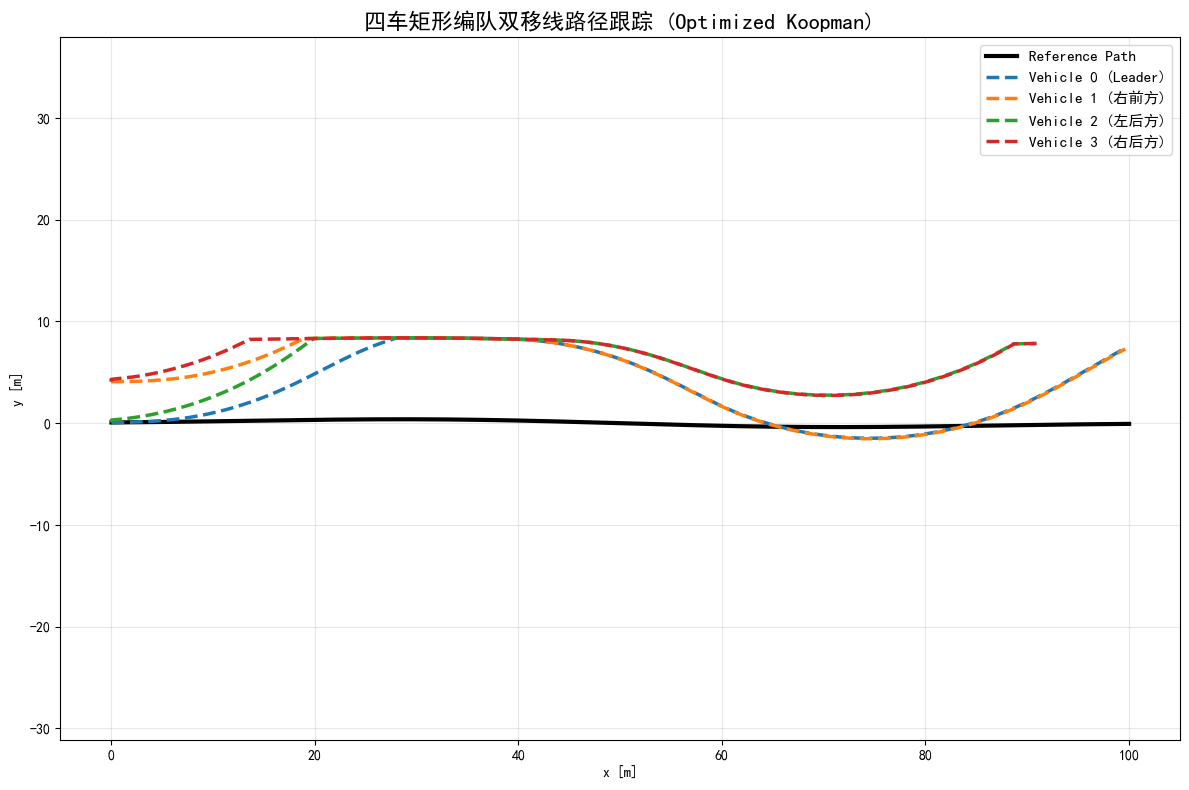

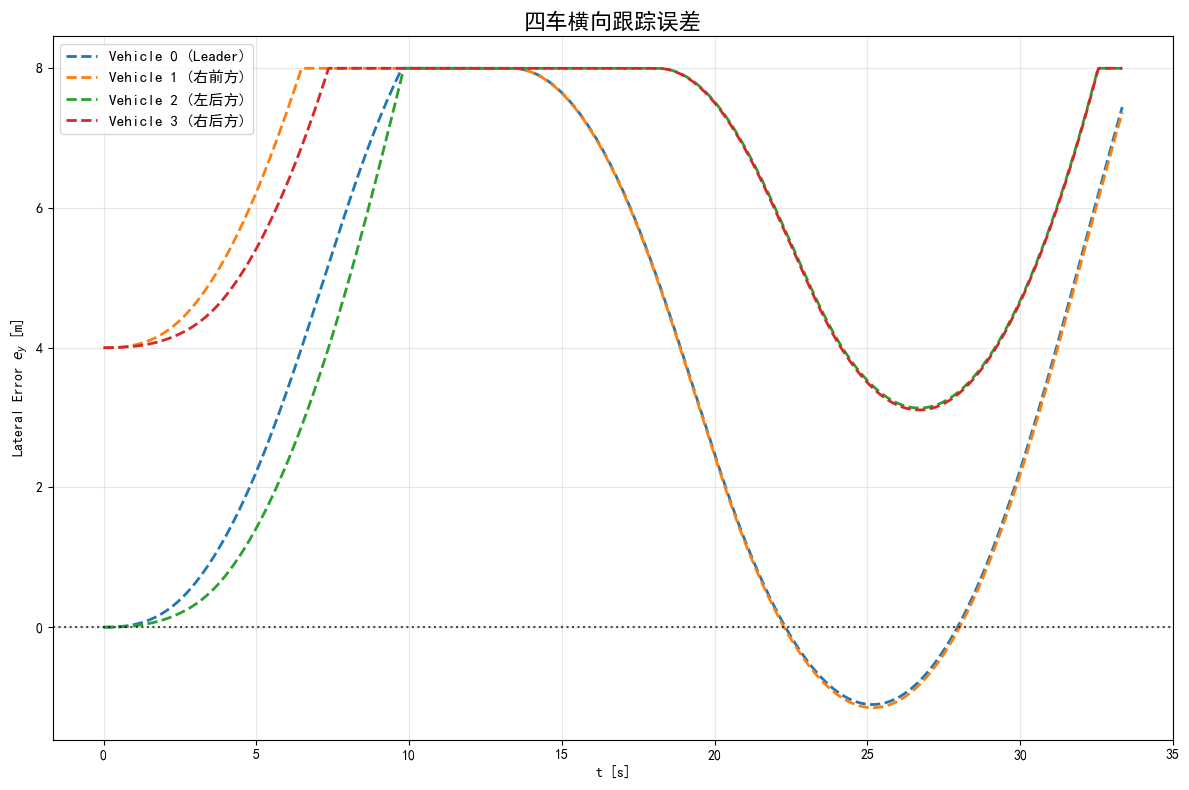

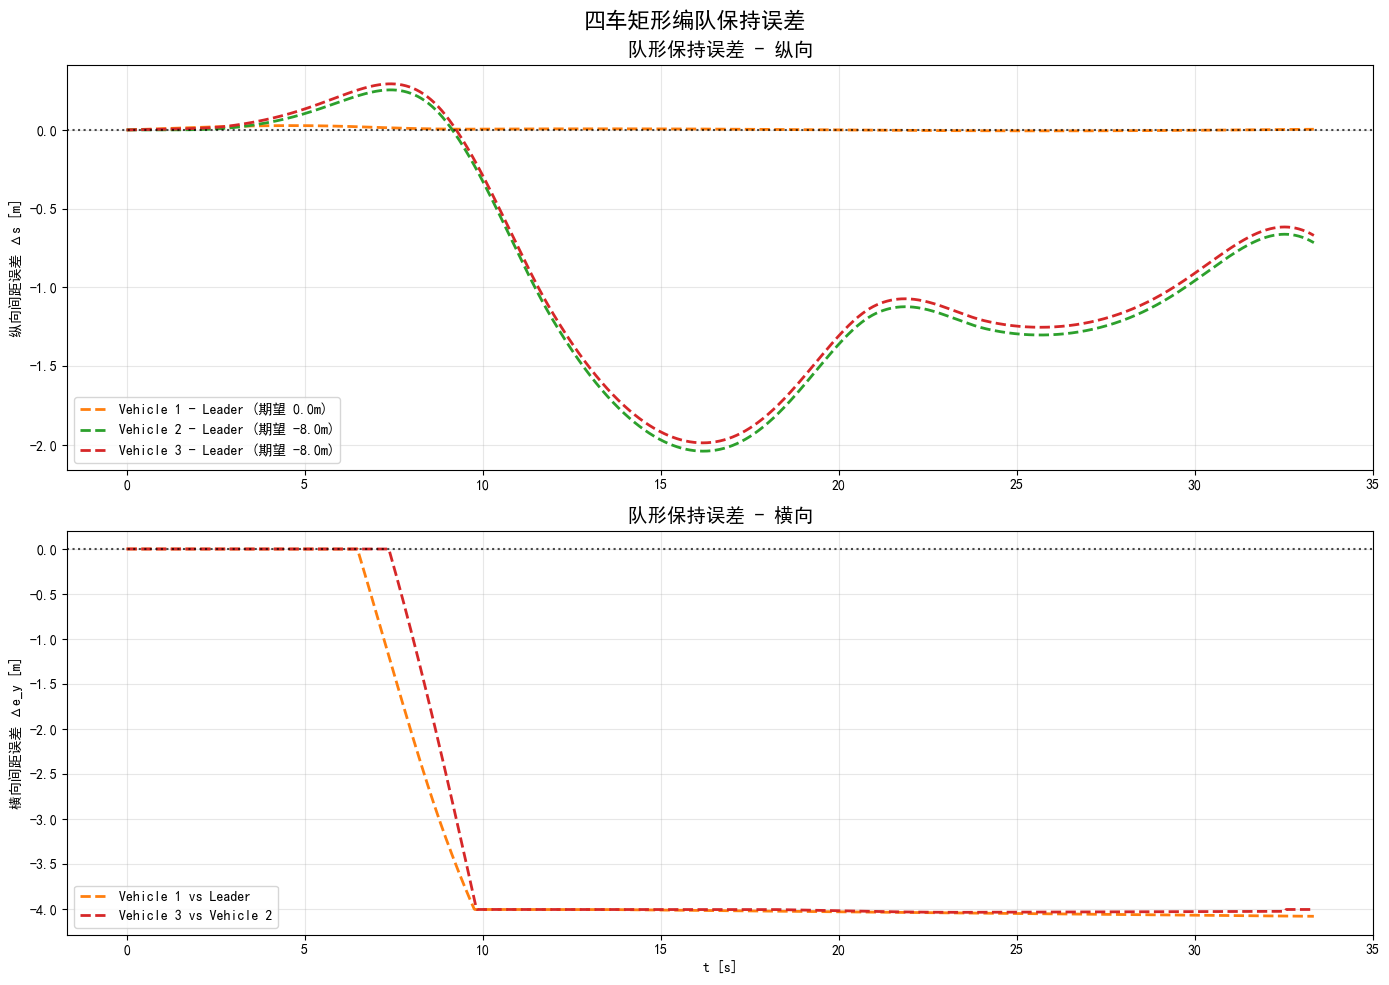

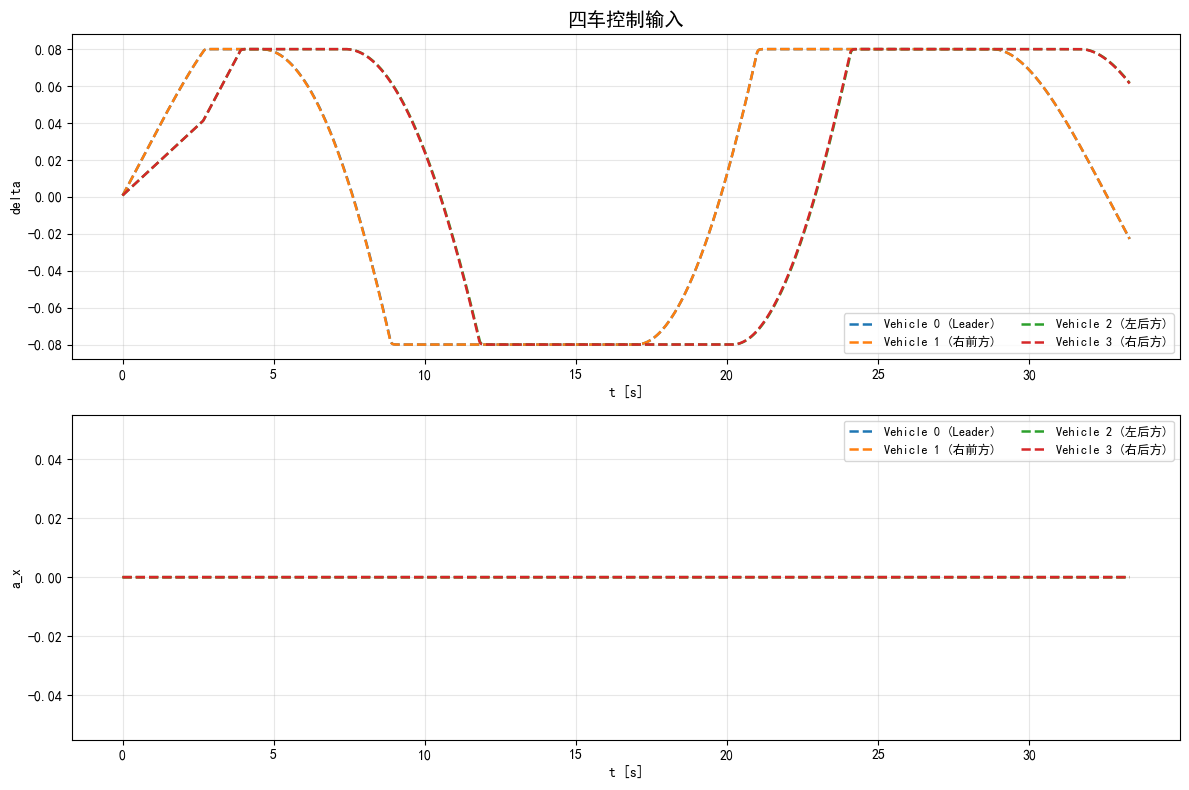

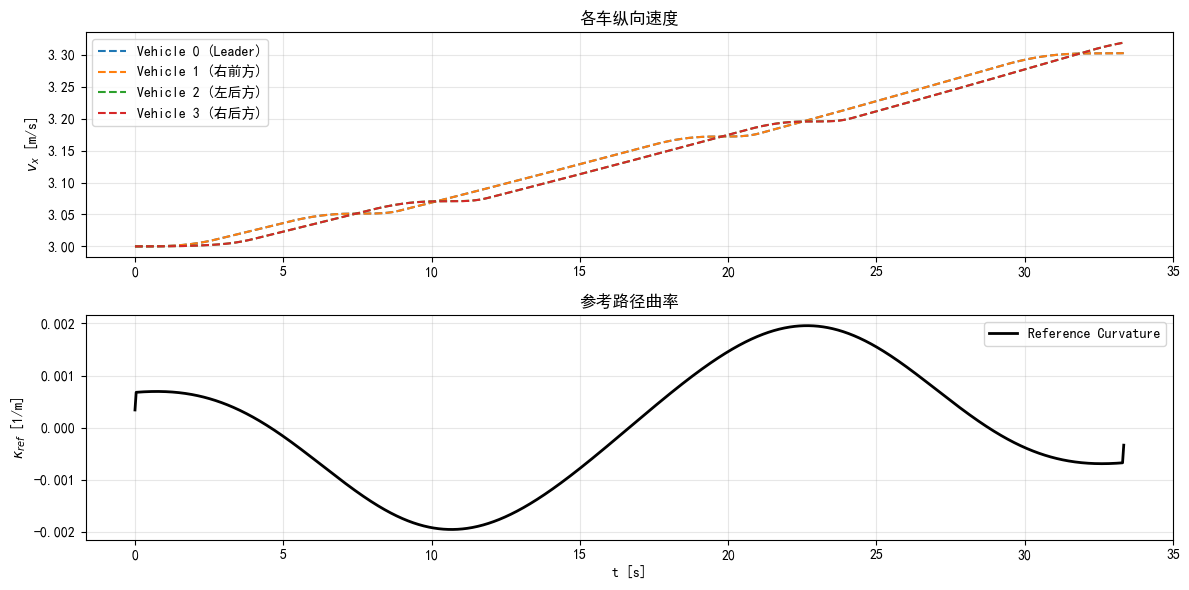

In [12]:
# =========================
# Plotting - 四车矩形编队
# =========================

# 先确定有效长度（防止非有限值导致绘图崩溃）
valid_len = traj_length
for idx in range(traj_length):
    if not np.all(np.isfinite(xt_actual_formation[idx, :])):
        valid_len = idx
        print(f"[WARN] 非有限状态出现在 step {idx}，绘图截断至此")
        break

# ====================== 1. 整体路径跟踪图 ======================
plt.figure(figsize=(12, 8))
plt.plot(x_path, y_ref_path, 'k-', linewidth=3, label="Reference Path")

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # 蓝、橙、绿、红
labels = ['Vehicle 0 (Leader)', 'Vehicle 1 (右前方)',
          'Vehicle 2 (左后方)', 'Vehicle 3 (右后方)']

for v in range(NUM_VEHICLES):
    idx = v * num_states
    s_actual = xt_actual_formation[:valid_len, idx]
    ey_actual = xt_actual_formation[:valid_len, idx + 1]

    x_actual, y_actual = frenet_to_global(
        s_actual, ey_actual,
        s_ref_path, x_path, y_ref_path, psi_ref_path
    )

    plt.plot(x_actual, y_actual, '--', color=colors[v],
             linewidth=2.5, label=labels[v])

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("四车矩形编队双移线路径跟踪 (Optimized Koopman)", fontsize=16)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

# ====================== 2. 每车横向误差 e_y ======================
plt.figure(figsize=(12, 8))
for v in range(NUM_VEHICLES):
    idx = v * num_states
    plt.plot(t_ref[:valid_len],
             xt_actual_formation[:valid_len, idx + 1],
             '--', color=colors[v], linewidth=2, label=labels[v])

plt.axhline(0, color='k', linestyle=':', alpha=0.7)
plt.xlabel("t [s]")
plt.ylabel("Lateral Error $e_y$ [m]")
plt.title("四车横向跟踪误差", fontsize=16)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ====================== 3. 队形保持误差 ======================
plt.figure(figsize=(14, 10))

# 纵向间距误差 (Δs)
plt.subplot(2, 1, 1)
for i in range(1, NUM_VEHICLES):
    idx_leader = 0 * num_states
    idx_v = i * num_states
    delta_s_actual = (xt_actual_formation[:valid_len, idx_v] -
                      xt_actual_formation[:valid_len, idx_leader])
    delta_s_desired = formation_offsets[i, 0]

    plt.plot(t_ref[:valid_len], delta_s_actual - delta_s_desired,
             '--', color=colors[i], linewidth=2,
             label=f'Vehicle {i} - Leader (期望 {delta_s_desired:.1f}m)')

plt.axhline(0, color='k', linestyle=':', alpha=0.7)
plt.ylabel("纵向间距误差 Δs [m]")
plt.title("队形保持误差 - 纵向", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# 横向间距误差 (Δe_y，仅左右车对)
plt.subplot(2, 1, 2)
# Vehicle 1 vs 0 (右前方)
delta_ey_1 = (xt_actual_formation[:valid_len, 1*num_states + 1] -
              xt_actual_formation[:valid_len, 0*num_states + 1])
plt.plot(t_ref[:valid_len], delta_ey_1 - DESIRED_LATERAL_GAP,
         '--', color=colors[1], linewidth=2, label='Vehicle 1 vs Leader')

# Vehicle 3 vs 2 (右后方)
delta_ey_3 = (xt_actual_formation[:valid_len, 3*num_states + 1] -
              xt_actual_formation[:valid_len, 2*num_states + 1])
plt.plot(t_ref[:valid_len], delta_ey_3 - DESIRED_LATERAL_GAP,
         '--', color=colors[3], linewidth=2, label='Vehicle 3 vs Vehicle 2')

plt.axhline(0, color='k', linestyle=':', alpha=0.7)
plt.xlabel("t [s]")
plt.ylabel("横向间距误差 Δe_y [m]")
plt.title("队形保持误差 - 横向", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.suptitle("四车矩形编队保持误差", fontsize=16)
plt.tight_layout()
plt.show()

# ====================== 4. 控制输入 ======================
plt.figure(figsize=(12, 8))
for i in range(num_inputs):
    plt.subplot(num_inputs, 1, i + 1)
    for v in range(NUM_VEHICLES):
        idx_u = v * num_inputs + i
        plt.plot(t_ref[:-1][:valid_len-1],
                 u_formation[:valid_len-1, idx_u],
                 '--', color=colors[v], linewidth=1.8,
                 label=labels[v])

    plt.ylabel(input_labels[i])
    plt.xlabel("t [s]")
    if i == 0:
        plt.title("四车控制输入", fontsize=14)
    plt.legend(fontsize=9, ncol=2)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ====================== 5. 纵向速度与曲率参考（可选辅助图） ======================
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
for v in range(NUM_VEHICLES):
    idx = v * num_states + 3  # v_x
    plt.plot(t_ref[:valid_len], xt_actual_formation[:valid_len, idx],
             '--', color=colors[v], label=labels[v])
plt.ylabel("$v_x$ [m/s]")
plt.title("各车纵向速度")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(t_ref[:valid_len], curvature_ref_path[:valid_len], 'k-', linewidth=2, label="Reference Curvature")
plt.ylabel("$\kappa_{ref}$ [1/m]")
plt.xlabel("t [s]")
plt.title("参考路径曲率")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()